Angle de correction appliqué : -1.012°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 42.0 V donc 3.734 m/s
Amplitude réelle (A)  : 19.62 mm
Fréquence (f)         : 14.88 Hz
Vitesse max (V_tip)   : 1.835 m/s


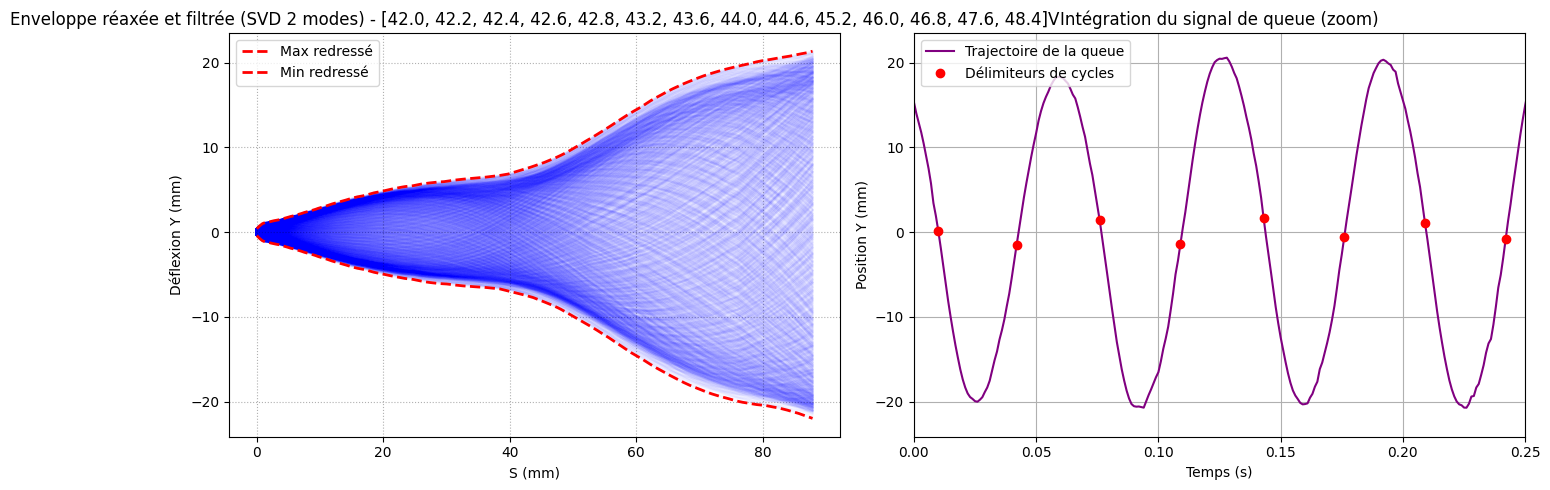

Angle de correction appliqué : -0.371°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 42.2 V donc 3.753 m/s
Amplitude réelle (A)  : 19.15 mm
Fréquence (f)         : 14.84 Hz
Vitesse max (V_tip)   : 1.786 m/s


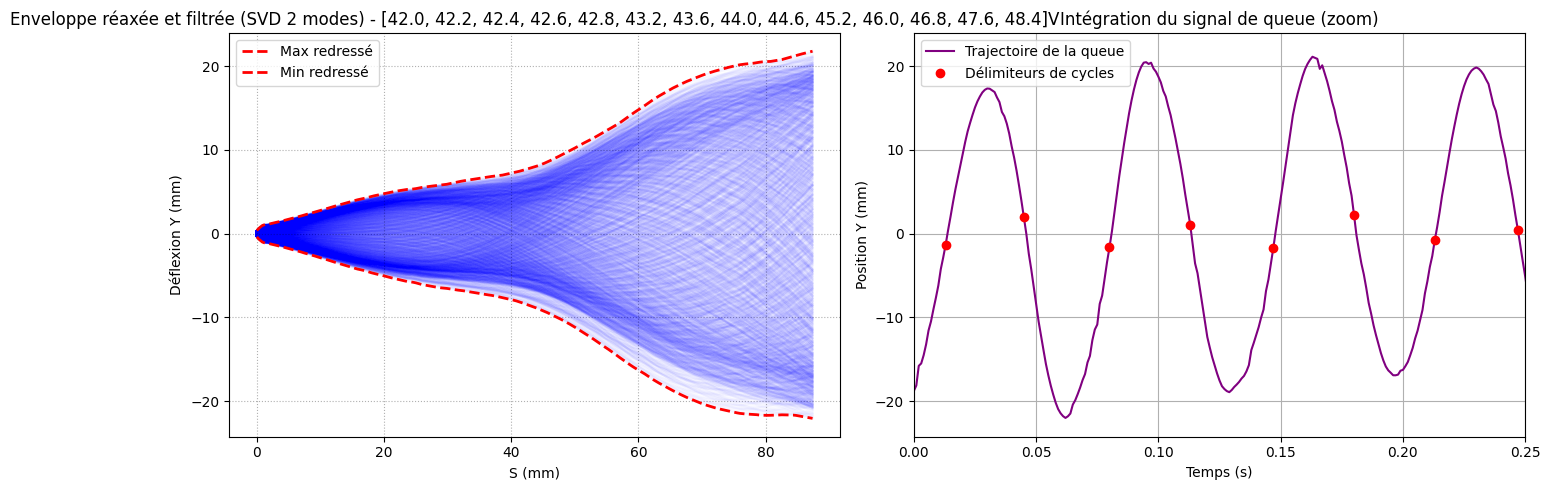

Angle de correction appliqué : -0.383°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 42.4 V donc 3.772 m/s
Amplitude réelle (A)  : 17.94 mm
Fréquence (f)         : 14.98 Hz
Vitesse max (V_tip)   : 1.689 m/s


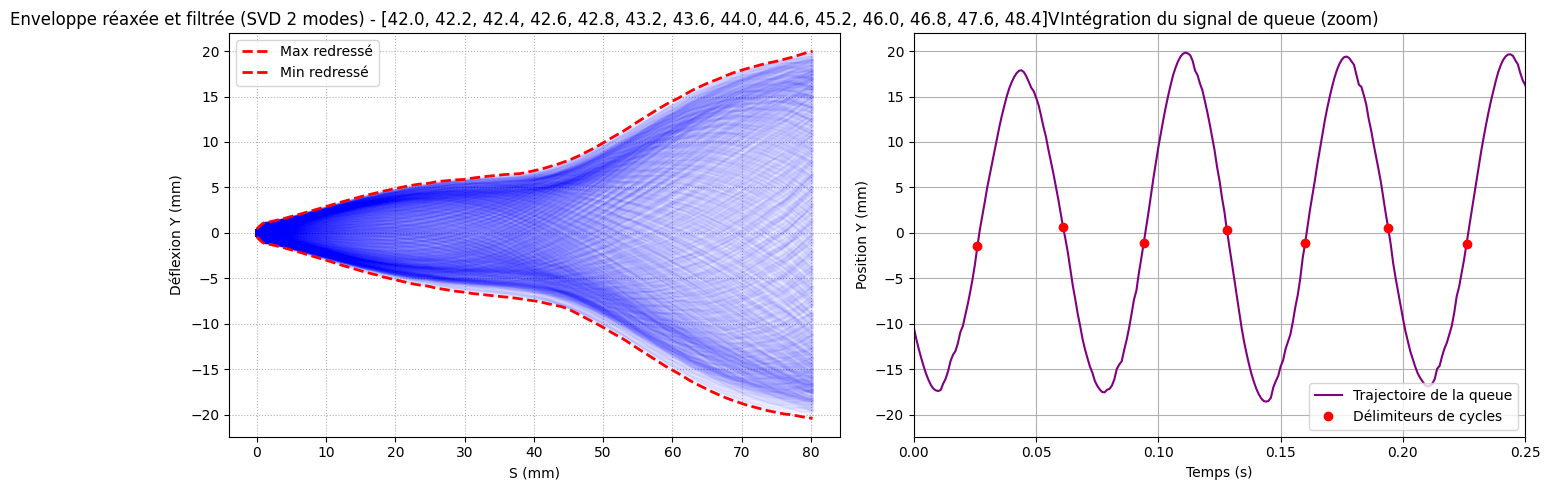

Angle de correction appliqué : -0.374°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 42.6 V donc 3.791 m/s
Amplitude réelle (A)  : 18.40 mm
Fréquence (f)         : 15.13 Hz
Vitesse max (V_tip)   : 1.750 m/s


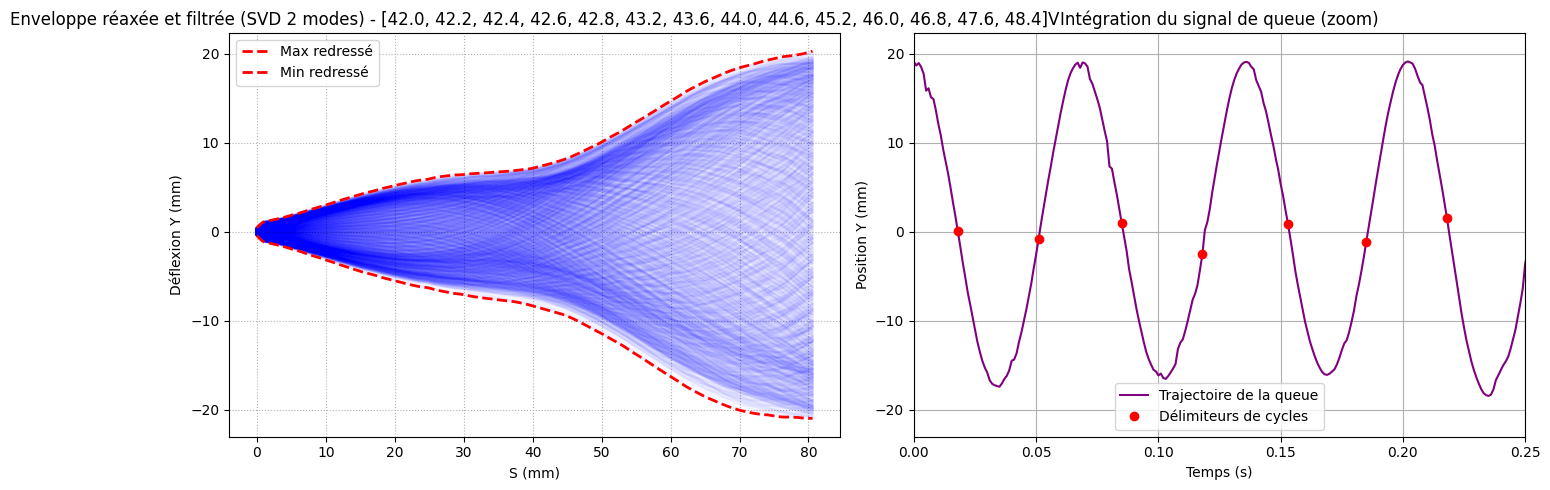

Angle de correction appliqué : -0.455°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 42.8 V donc 3.810 m/s
Amplitude réelle (A)  : 18.75 mm
Fréquence (f)         : 14.84 Hz
Vitesse max (V_tip)   : 1.750 m/s


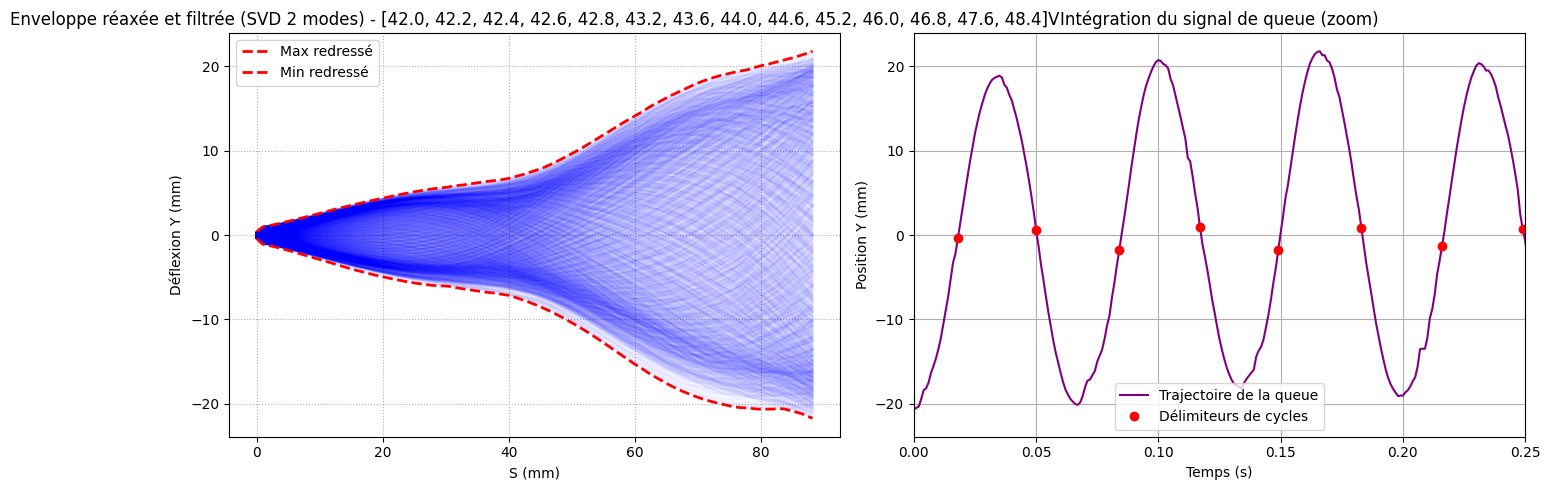

Angle de correction appliqué : -0.739°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 43.2 V donc 3.848 m/s
Amplitude réelle (A)  : 18.81 mm
Fréquence (f)         : 15.30 Hz
Vitesse max (V_tip)   : 1.809 m/s


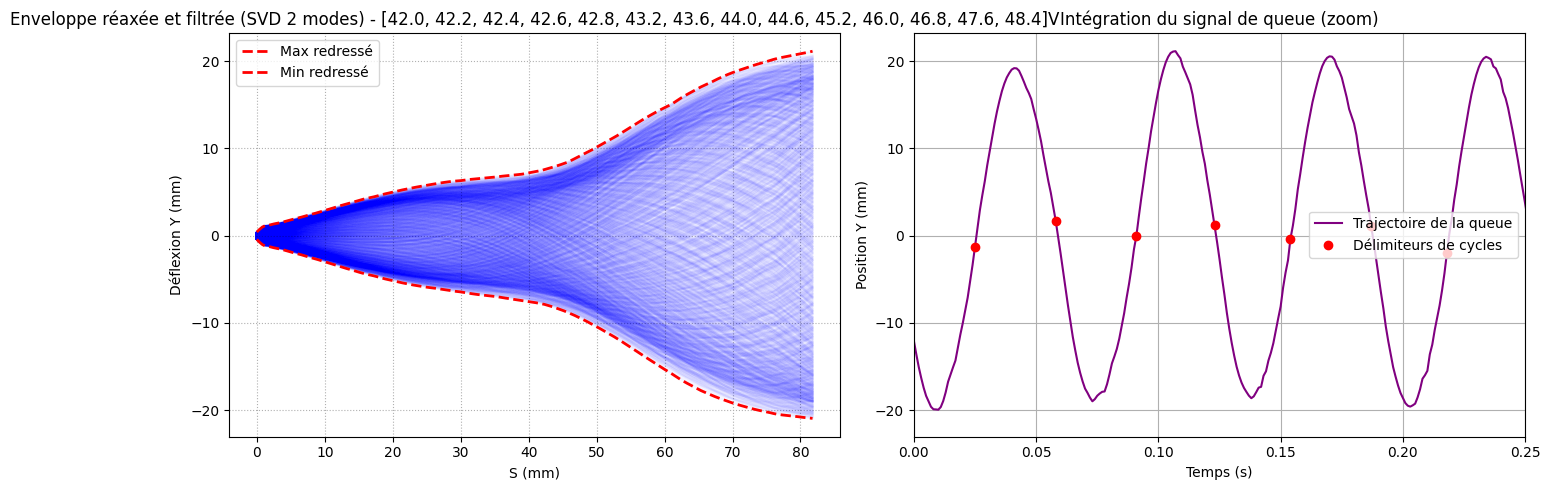

Angle de correction appliqué : -0.286°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 43.6 V donc 3.886 m/s
Amplitude réelle (A)  : 20.67 mm
Fréquence (f)         : 15.51 Hz
Vitesse max (V_tip)   : 2.015 m/s


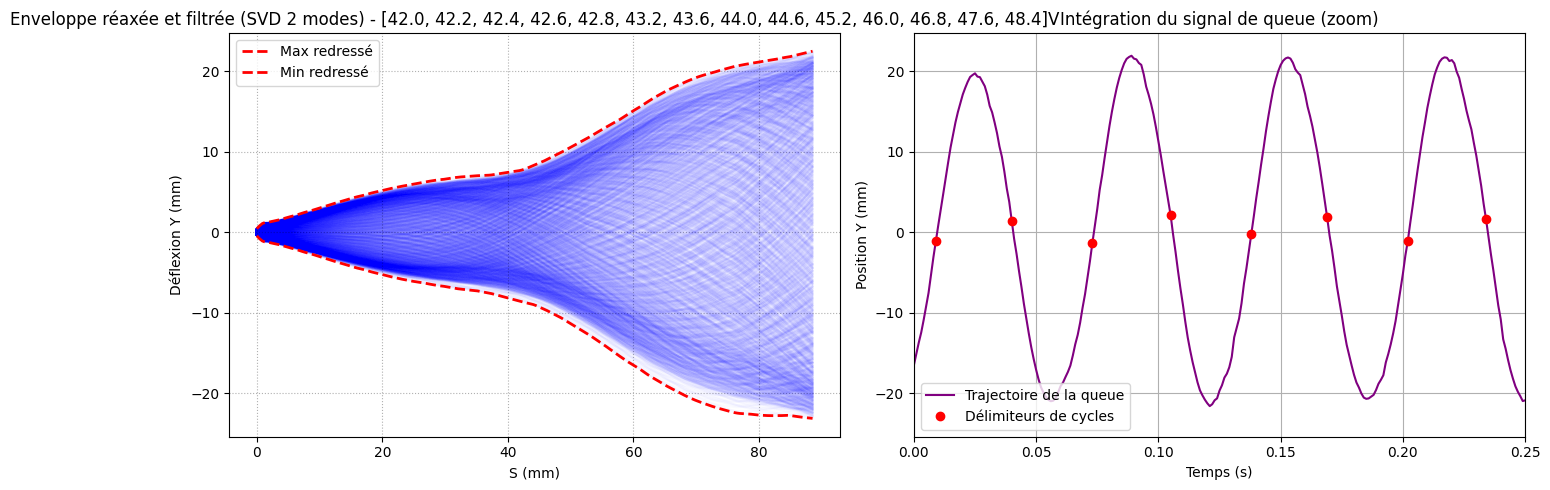

Angle de correction appliqué : -0.584°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 44.0 V donc 3.924 m/s
Amplitude réelle (A)  : 19.55 mm
Fréquence (f)         : 15.60 Hz
Vitesse max (V_tip)   : 1.917 m/s


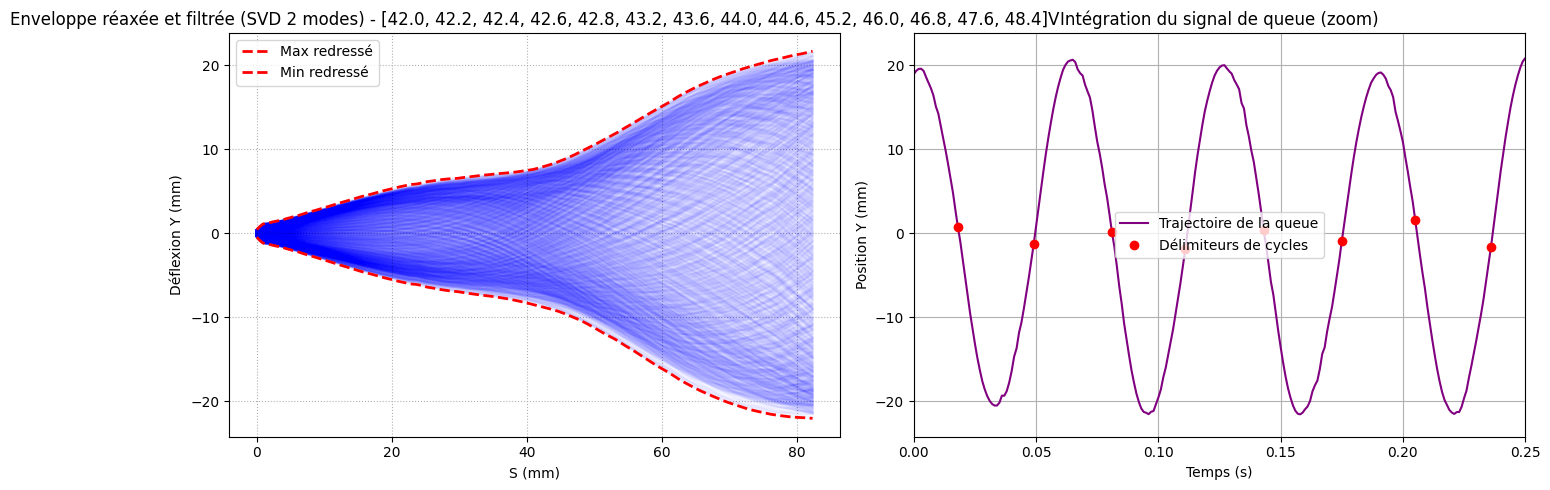

Angle de correction appliqué : -0.588°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 44.6 V donc 3.981 m/s
Amplitude réelle (A)  : 18.59 mm
Fréquence (f)         : 15.79 Hz
Vitesse max (V_tip)   : 1.845 m/s


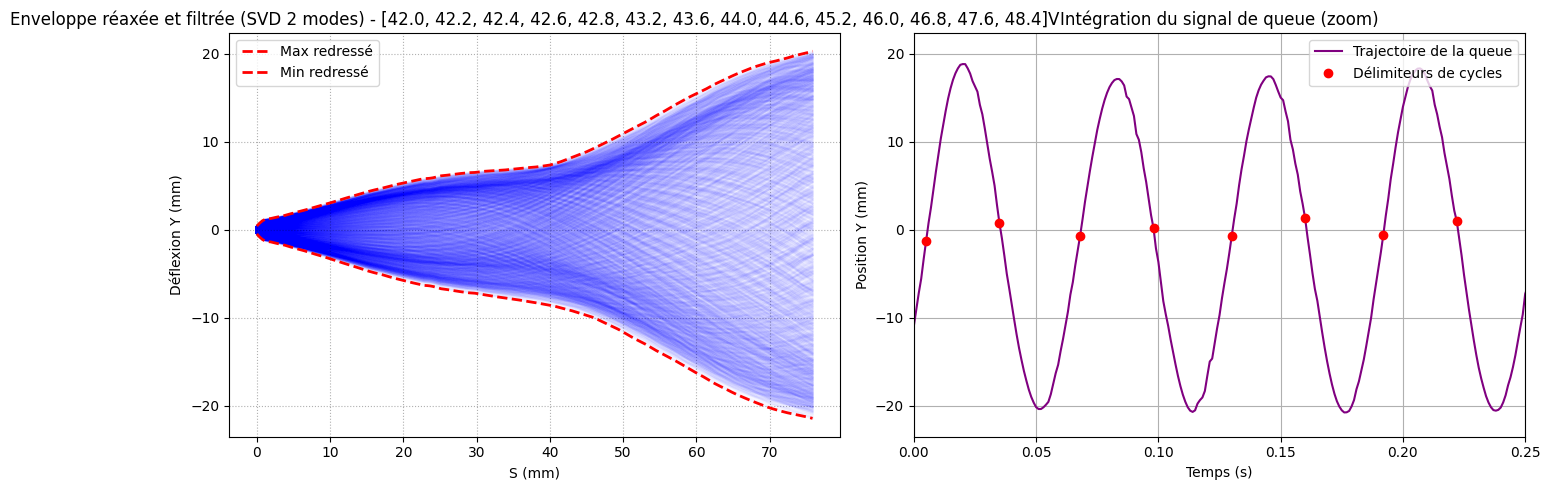

Angle de correction appliqué : -0.154°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 45.2 V donc 4.037 m/s
Amplitude réelle (A)  : 21.01 mm
Fréquence (f)         : 15.75 Hz
Vitesse max (V_tip)   : 2.080 m/s


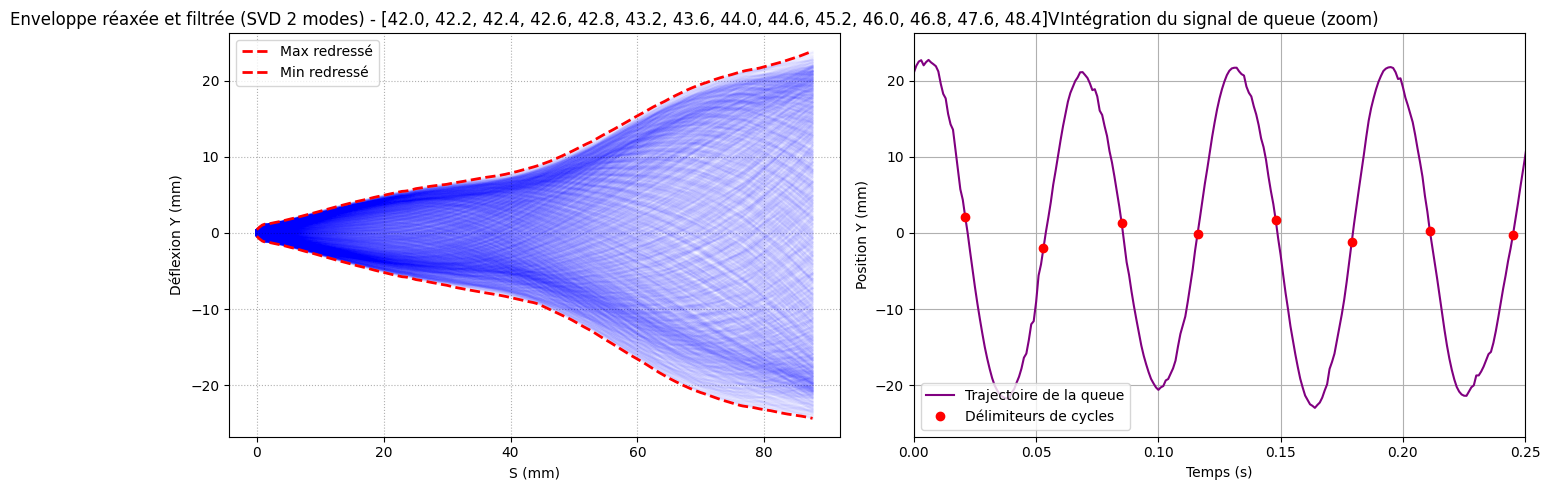

Angle de correction appliqué : -0.551°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 46.0 V donc 4.113 m/s
Amplitude réelle (A)  : 22.17 mm
Fréquence (f)         : 16.24 Hz
Vitesse max (V_tip)   : 2.265 m/s


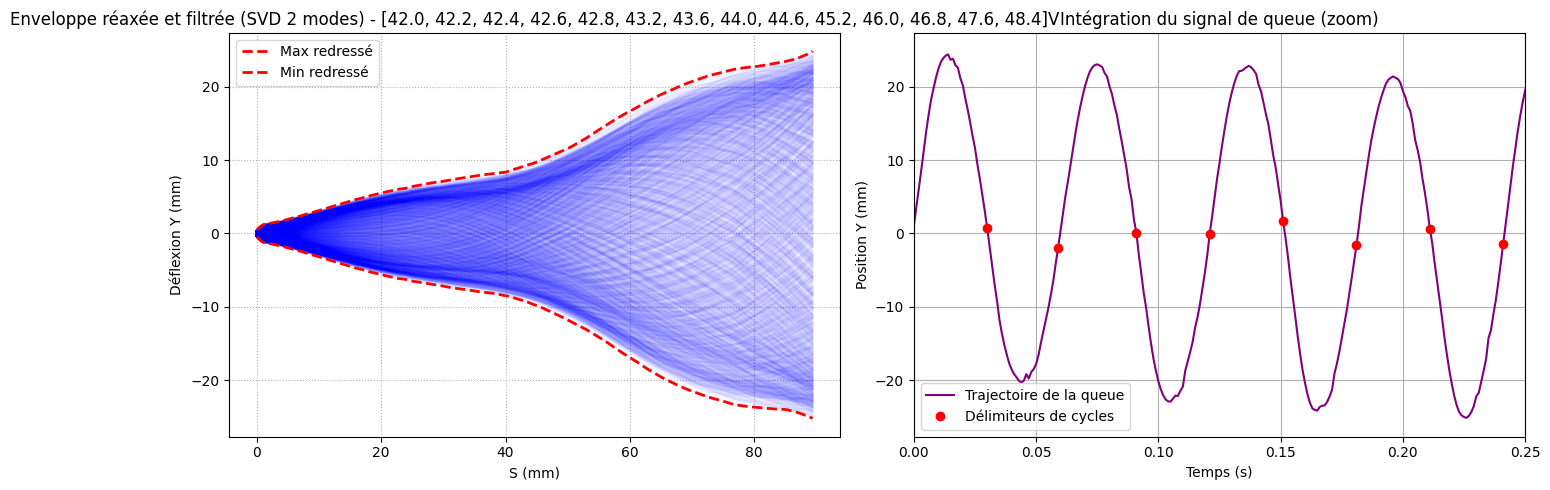

Angle de correction appliqué : -0.791°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 46.8 V donc 4.189 m/s
Amplitude réelle (A)  : 21.39 mm
Fréquence (f)         : 16.38 Hz
Vitesse max (V_tip)   : 2.202 m/s


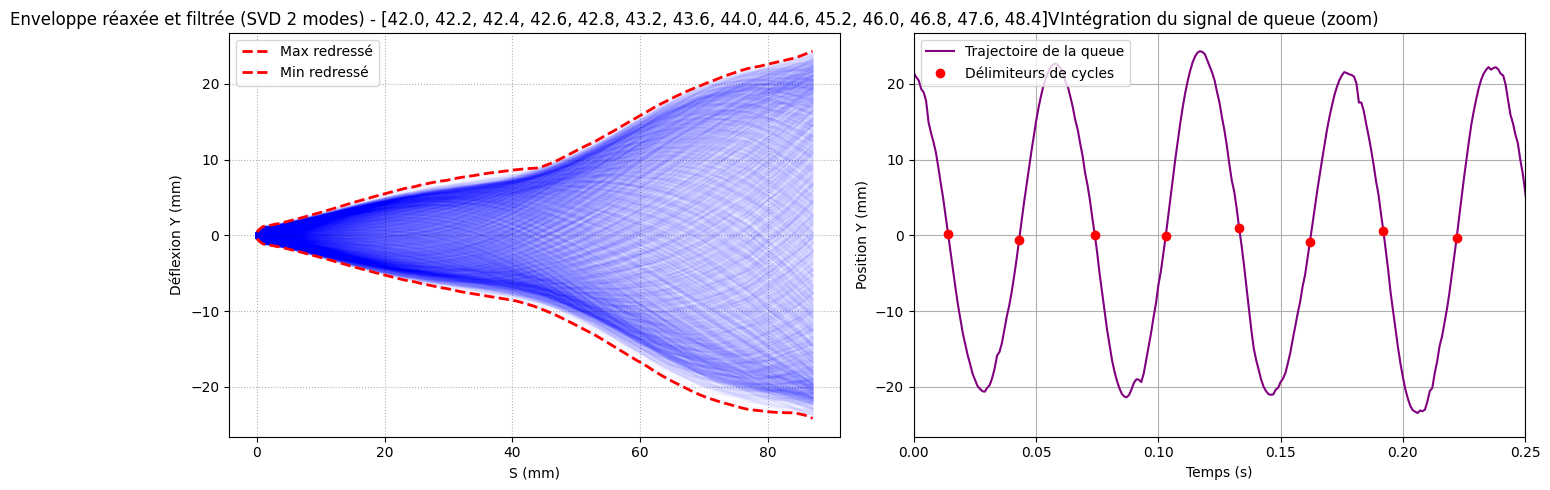

Angle de correction appliqué : -0.709°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 47.6 V donc 4.265 m/s
Amplitude réelle (A)  : 24.14 mm
Fréquence (f)         : 16.30 Hz
Vitesse max (V_tip)   : 2.472 m/s


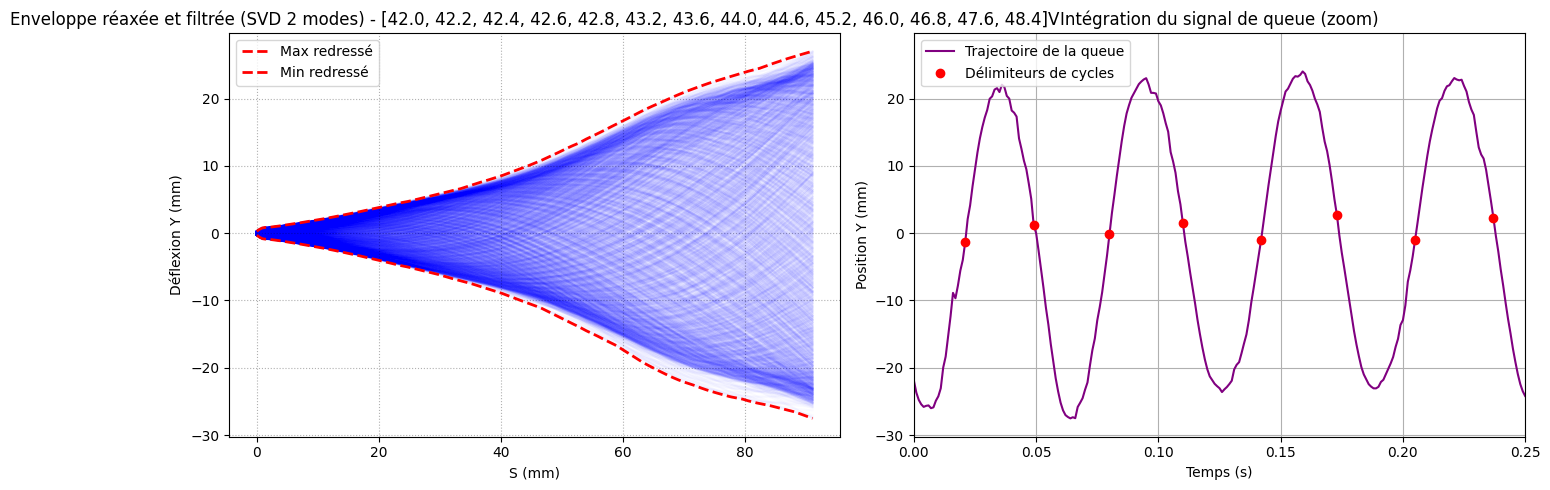

Angle de correction appliqué : -0.242°

--- RÉSULTATS CINÉMATIQUES GLOBAUX ---
Vitesse soufflerie   : 48.4 V donc 4.340 m/s
Amplitude réelle (A)  : 21.09 mm
Fréquence (f)         : 16.47 Hz
Vitesse max (V_tip)   : 2.182 m/s


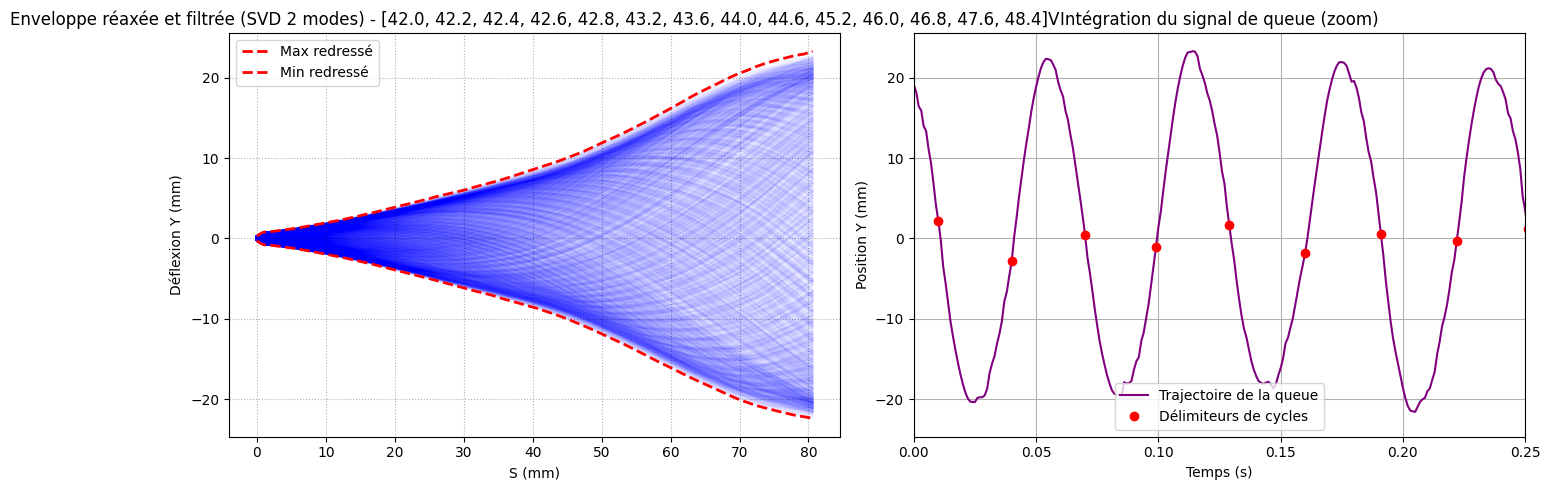

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

def veloc_tunel(V):
    tunel_v = pd.read_csv('tunel_viento.csv', header=None)
    deltaV, U = tunel_v.to_numpy().T
    p1 = np.polyfit(deltaV, U, 1)
    UdeltaV = np.poly1d(p1)
    if not np.isscalar(V):
        velocidad = np.zeros_like(V)
        for i, Vi in enumerate(V):
            velocidad[i] = UdeltaV(Vi) if Vi != 0 else 0
    else:
        velocidad = UdeltaV(V) if V != 0 else 0
    return velocidad

# Paramètres physiques
L_flag_t = 0.12
L_flag_mm_t = 120.0
rho_50 = 1305
m_flag = rho_50 * 50e-6  
B_flag = 4.3e-5 
rho_air = 1.2 
H_flag_t = 0.1713
fps = 1000.0
volts = [42.0, 42.2, 42.4, 42.6, 42.8, 43.2, 43.6, 44.0, 44.6, 45.2, 46.0, 46.8, 47.6, 48.4]

for v in volts :
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    Y_brut = data['Y'] / 1000.0  # Passage en mètres
    S = data['S'][0] / 1000.0
    
    # réaxage
    #  calcule la forme moyenne (qui devrait être horizontale)
    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    
    #  calcule l'angle d'inclinaison
    slope, intercept, _, _, _ = linregress(S, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    print(f"Angle de correction appliqué : {np.degrees(angle_rad):.3f}°")
    
    # matrice de rotation inverse (pour redresser le drapeau)
    Y_corrige = np.zeros_like(Y_brut)
    cos_a = np.cos(-angle_rad)
    sin_a = np.sin(-angle_rad)
    
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S * sin_a + Y_brut[i, :] * cos_a
    
    # signal réaxé, on peut le centrer sur 0
    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    
    # svd mode 1 et 2
    U, Sigma, Vt = np.linalg.svd(Y_centré, full_matrices=False)
    
    # reconstruit un signal sans bruit de caméra
    Y_propre = np.dot(U[:, :2] * Sigma[:2], Vt[:2, :])
    
    # queue réaxée et lissée
    tip_signal = Y_propre[:, -1]
    
    # Passages par zéro pour délimiter les cycles
    zero_crossings = np.where(np.diff(np.sign(tip_signal)))[0]
    
    amplitudes_deduites = []
    frequences = []
    vitesses_moyennes = []
    
    # cycles complets (un aller-retour = 3 passages par zéro)
    for i in range(len(zero_crossings) - 2):
        idx_debut = zero_crossings[i]
        idx_fin = zero_crossings[i+2]
        
        #trajectoire pour 1 période
        chemin = tip_signal[idx_debut:idx_fin]
        temps_cycle = (idx_fin - idx_debut) / fps
        
        # somme absolue des petits déplacements
        distance_parcourue = np.sum(np.abs(np.diff(chemin)))
        
        amp = distance_parcourue / 4.0  #  cycle = 4 fois l'amplitude
        v_moy = distance_parcourue / temps_cycle
        
        amplitudes_deduites.append(amp)
        vitesses_moyennes.append(v_moy)
        frequences.append(1.0 / temps_cycle)
    

    A_finale = np.mean(amplitudes_deduites)
    f_finale = np.mean(frequences)
    # Modèle harmonique : V_max = V_moyenne * (pi/2)
    V_tip_finale = np.mean(vitesses_moyennes) * (np.pi / 2.0)
    U_vent_tempo = veloc_tunel(v)
    
    print("\n--- RÉSULTATS CINÉMATIQUES GLOBAUX ---")
    print(f"Vitesse soufflerie   : {v:.1f} V donc {U_vent_tempo:.3f} m/s")
    print(f"Amplitude réelle (A)  : {A_finale * 1000:.2f} mm")
    print(f"Fréquence (f)         : {f_finale:.2f} Hz")
    print(f"Vitesse max (V_tip)   : {V_tip_finale:.3f} m/s")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    #l'enveloppe redressée
    for i in range(Y_propre.shape[0]):
        ax1.plot(S * 1000, Y_propre[i, :] * 1000, color='blue', alpha=0.02)
    ax1.plot(S * 1000, np.max(Y_propre, axis=0) * 1000, 'r--', linewidth=2, label='Max redressé')
    ax1.plot(S * 1000, np.min(Y_propre, axis=0) * 1000, 'r--', linewidth=2, label='Min redressé')
    ax1.set_title(f"Enveloppe réaxée et filtrée (SVD 2 modes) - {volts}V")
    ax1.set_xlabel("S (mm)")
    ax1.set_ylabel("Déflexion Y (mm)")
    ax1.legend()
    ax1.grid(True, linestyle=':')
    
    #suivi de la queue
    ax2.plot(np.arange(len(tip_signal))/fps, tip_signal*1000, color='purple', label="Trajectoire de la queue")
    ax2.plot(zero_crossings/fps, tip_signal[zero_crossings]*1000, 'ro', label="Délimiteurs de cycles")
    ax2.set_title("Intégration du signal de queue (zoom)")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Position Y (mm)")
    ax2.set_xlim(0, 0.25)
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

Vitesse soufflerie   : 42.2 V donc 4.340 m/s
Amplitude absolue (Outliers) : 21.79 mm
Amplitude Typique (Zone bleue): 19.56 mm


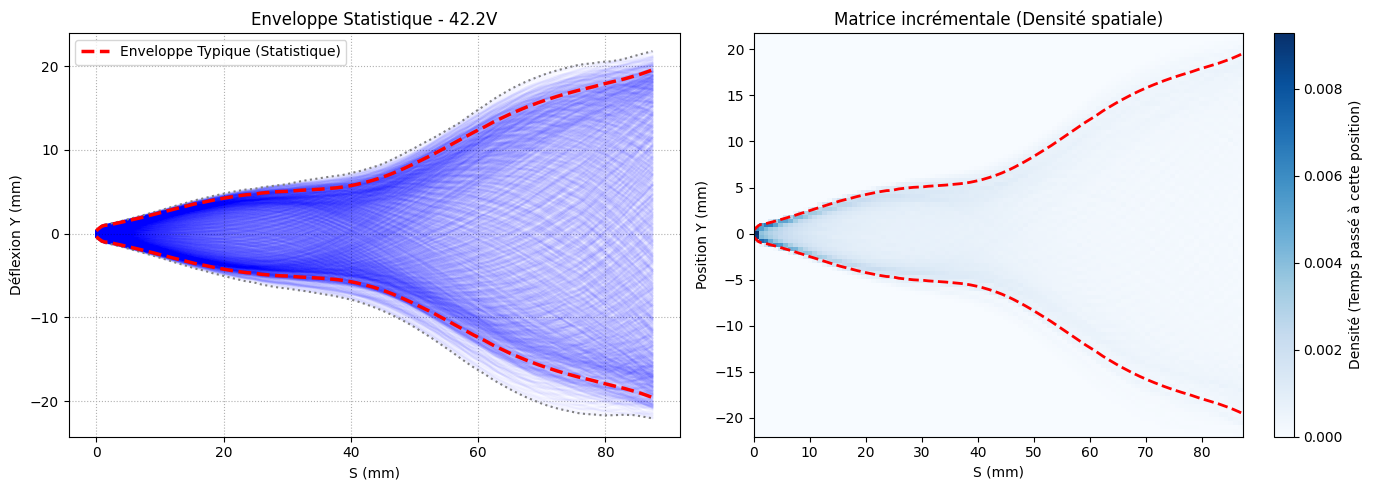

In [2]:
volts = [42.2] 

for v in volts :
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    Y_brut = data['Y'] / 1000.0  # Passage en mètres
    S = data['S'][0] / 1000.0
    #reaxage
    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S * sin_a + Y_brut[i, :] * cos_a
    
    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    
    U, Sigma, Vt = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U[:, :2] * Sigma[:2], Vt[:2, :])
    tip_signal = Y_propre[:, -1]
    
    # enveloppe stat = la zone la plus bleue
    # calcule l'écart-type (RMS) de chaque point le long du drapeau
    Y_rms = np.std(Y_propre, axis=0)
    
    #convertit ce RMS en "Amplitude Crête Typique" (facteur sqrt(2))
    enveloppe_stat_max = Y_rms * np.sqrt(2)
    enveloppe_stat_min = -Y_rms * np.sqrt(2)
    
    Amplitude_Statistique = enveloppe_stat_max[-1]
    print(f"Vitesse soufflerie   : {v:.1f} V donc {U_vent_tempo:.3f} m/s")
    print(f"Amplitude absolue (Outliers) : {np.max(tip_signal)*1000:.2f} mm")
    print(f"Amplitude Typique (Zone bleue): {Amplitude_Statistique*1000:.2f} mm")

    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # superposition et Enveloppe Statistique
    for i in range(Y_propre.shape[0]):
        ax1.plot(S * 1000, Y_propre[i, :] * 1000, color='blue', alpha=0.02)
        
    # enveloppe des valeurs extrêmes ancienne méthode, en gris transparent pour comparer)
    ax1.plot(S * 1000, np.max(Y_propre, axis=0) * 1000, color='gray', linestyle=':', linewidth=1.5)
    ax1.plot(S * 1000, np.min(Y_propre, axis=0) * 1000, color='gray', linestyle=':', linewidth=1.5)
    
    #enveloppe nouvelle méthode
    ax1.plot(S * 1000, enveloppe_stat_max * 1000, 'r--', linewidth=2.5, label='Enveloppe Typique (Statistique)')
    ax1.plot(S * 1000, enveloppe_stat_min * 1000, 'r--', linewidth=2.5)
    
    ax1.set_title(f"Enveloppe Statistique - {v}V")
    ax1.set_xlabel("S (mm)")
    ax1.set_ylabel("Déflexion Y (mm)")
    ax1.legend()
    ax1.grid(True, linestyle=':')
    
    # matrice incrémentale
    # On aplatit les matrices S et Y pour que la fonction histogram2d puisse compter tous les points
    S_matrice = np.tile(S, (Y_propre.shape[0], 1))
    S_flat = S_matrice.flatten() * 1000
    Y_flat = Y_propre.flatten() * 1000
    
    # carte densité de probabilité
    h = ax2.hist2d(S_flat, Y_flat, bins=[100, 100], cmap='Blues', density=True)
    fig.colorbar(h[3], ax=ax2, label='Densité (Temps passé à cette position)')
    
    #  superpose notre ligne rouge pour prouver qu'elle suit la zone dense
    ax2.plot(S * 1000, enveloppe_stat_max * 1000, 'r--', linewidth=2)
    ax2.plot(S * 1000, enveloppe_stat_min * 1000, 'r--', linewidth=2)
    
    ax2.set_title("Matrice incrémentale (Densité spatiale)")
    ax2.set_xlabel("S (mm)")
    ax2.set_ylabel("Position Y (mm)")
    
    plt.tight_layout()
    plt.show()

In [3]:
from scipy.signal import find_peaks
from sklearn.linear_model import Ridge
import pandas as pd

volts = [42.0, 42.2, 42.4, 42.6, 42.8, 43.2, 43.6, 44.0, 44.6, 45.2, 46.0, 46.8, 47.6, 48.4] #47.6, 48.4 devraient être exclus psq repliement
    
# Racines pour les modes d'Euler-Bernoulli
beta_L = np.array([1.87510407, 4.69409113, 7.85475744, 10.99554073])

def mode_EB(x, beta_L_val, L):
    b = beta_L_val / L
    sigma = (np.cosh(beta_L_val) + np.cos(beta_L_val)) / (np.sinh(beta_L_val) + np.sin(beta_L_val))
    return np.cosh(b*x) - np.cos(b*x) - sigma * (np.sinh(b*x) - np.sin(b*x))

def mode_EB_dx2(x, beta_L_val, L):
    b = beta_L_val / L
    sigma = (np.cosh(beta_L_val) + np.cos(beta_L_val)) / (np.sinh(beta_L_val) + np.sin(beta_L_val))
    return (b**2) * (np.cosh(b*x) + np.cos(b*x) - sigma * (np.sinh(b*x) + np.sin(b*x)))

def mode_EB_dx4(x, beta_L_val, L):
    b = beta_L_val / L
    return (b**4) * mode_EB(x, beta_L_val, L)

results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz') #en vrai c'est 1000Hz
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)


    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a


    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_t) # dt adimensionné
    
    #données réaxées pour Euler-Bernoulli 
    s_axis = S_brut / L_flag_mm_t 
    Y = Y_corrige / L_flag_mm_t 

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_t 
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_t)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_t) * (L_flag_t**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_t) * (L_flag_t**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)


    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    

    U_svd, Sigma_svd, Vt_svd = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U_svd[:, :2] * Sigma_svd[:2], Vt_svd[:2, :])
    
    tip_signal_t = Y_propre[:, -1] / 1000.0
    
    # amplitude Statistique (RMS)
    amplitude_moyenne_t = np.std(tip_signal_t) * np.sqrt(2)
    
    # fréquence (Passages par zéro)
    zero_crossings = np.where(np.diff(np.sign(tip_signal_t)))[0]
    if len(zero_crossings) < 4:
        print(f"  -> Attention, pas assez d'oscillations détectées pour {v} V.")
        continue
        
    periodes_en_points_t = np.diff(zero_crossings[::2]) 
    periode_moyenne_sec_t = np.mean(periodes_en_points_t) / fps
    freq_precise_t = 1.0 / periode_moyenne_sec_t
    
    # vitesse instantanée pour chaque frame
    v_tip_instantanee_t = np.gradient(tip_signal_t, dt_brut) 
    
    # "Vitesse Crête Typique" avec la méthode RMS
    v_tip_reelle_t = np.std(v_tip_instantanee_t) * np.sqrt(2)
    
    #comparaison avec le modèle harmonique 
    v_tip_harmonique_t = 2 * np.pi * freq_precise_t * amplitude_moyenne_t
    print(f"Vitesse Harmonique: {v_tip_harmonique_t:.3f} | Vitesse Réelle: {v_tip_reelle_t:.3f}")
    m_air_displaced_t = rho_air * np.pi * H_flag_t / 4
    

    Y_t = np.gradient(Y_pur, dt, axis=0)
    Y_tt = np.gradient(Y_t, dt, axis=0)
    Y_ts = np.gradient(Y_t, s_axis, axis=1) 

    b_time = 5 
    b_space = 5
    
    Y_tt_flat = Y_tt[b_time:-b_time, b_space:-b_space].flatten()
    Y_ts_flat = Y_ts[b_time:-b_time, b_space:-b_space].flatten()
    Y_ss_flat = Y_ss_pur[b_time:-b_time, b_space:-b_space].flatten()
    Y_ssss_flat = Y_ssss_pur[b_time:-b_time, b_space:-b_space].flatten()

    Y_s_flat = np.gradient(Y_pur, s_axis, axis=1)[b_time:-b_time, b_space:-b_space].flatten()
    Y_t_flat = Y_t[b_time:-b_time, b_space:-b_space].flatten()
    
    W_norm = Y_s_flat + Y_t_flat
    Y_resis_flat = np.abs(W_norm) * W_norm

    X_features = np.column_stack([Y_ts_flat, Y_ss_flat, Y_ssss_flat, Y_resis_flat])
    target = Y_tt_flat

    X_scales = np.std(X_features, axis=0)
    X_scales[X_scales == 0] = 1.0 
    X_features_scaled = X_features / X_scales

    modele = Ridge(alpha=5.0, fit_intercept=False) 
    modele.fit(X_features_scaled, target)
    vrais_coefs = modele.coef_ / X_scales

    C_ts = vrais_coefs[0]
    C_ss = vrais_coefs[1]
    C_ssss = vrais_coefs[2]
    C_resis = vrais_coefs[3]

    M_air_t = (-C_ts * m_flag) / (2 + C_ts)
    M_totale_t = m_flag + M_air_t
    Tension_moyenne_t = (U_vent**2) * (C_ss * M_totale_t + M_air_t)
    Cd_calcule_t = - (2 * M_totale_t * C_resis) / (rho_air * L_flag_t)
    D_calcule_t = - C_ssss * M_totale_t * (U_vent**2) * (L_flag_t**2)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_t, 4),
        'Frequence_Hz': round(freq_precise_t, 3),
        'V_harm_ms': round(v_tip_harmonique_t, 3),
        'V_battement_ms': round(v_tip_reelle_t, 3),
        'M_air_cylindre_kg': round(m_air_displaced_t, 6),
        'M_air_SINDy_kg': round(M_air_t, 6),
        'Tension_N_m': round(Tension_moyenne_t, 4),
        'Cd_SINDy': round(Cd_calcule_t, 3),
        'Rigidite_D': round(D_calcule_t, 8)
    })

df_final = pd.DataFrame(results)
print("\n=== Synthèse Complète ===")
print(df_final)
df_final.to_csv('synthese_complete.csv', index=False)


Traitement de la prise 42.0 V...
Vitesse Harmonique: 1.898 | Vitesse Réelle: 1.912

Traitement de la prise 42.2 V...
Vitesse Harmonique: 1.823 | Vitesse Réelle: 1.849

Traitement de la prise 42.4 V...
Vitesse Harmonique: 1.721 | Vitesse Réelle: 1.727

Traitement de la prise 42.6 V...
Vitesse Harmonique: 1.782 | Vitesse Réelle: 1.794

Traitement de la prise 42.8 V...
Vitesse Harmonique: 1.806 | Vitesse Réelle: 1.825

Traitement de la prise 43.2 V...
Vitesse Harmonique: 1.847 | Vitesse Réelle: 1.854

Traitement de la prise 43.6 V...
Vitesse Harmonique: 2.062 | Vitesse Réelle: 2.093

Traitement de la prise 44.0 V...
Vitesse Harmonique: 1.951 | Vitesse Réelle: 1.967

Traitement de la prise 44.6 V...
Vitesse Harmonique: 1.874 | Vitesse Réelle: 1.884

Traitement de la prise 45.2 V...
Vitesse Harmonique: 2.140 | Vitesse Réelle: 2.162

Traitement de la prise 46.0 V...
Vitesse Harmonique: 2.333 | Vitesse Réelle: 2.355

Traitement de la prise 46.8 V...
Vitesse Harmonique: 2.289 | Vitesse Réelle

C:\Users\alice\AppData\Local\Temp\ipykernel_11504\2677439441.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


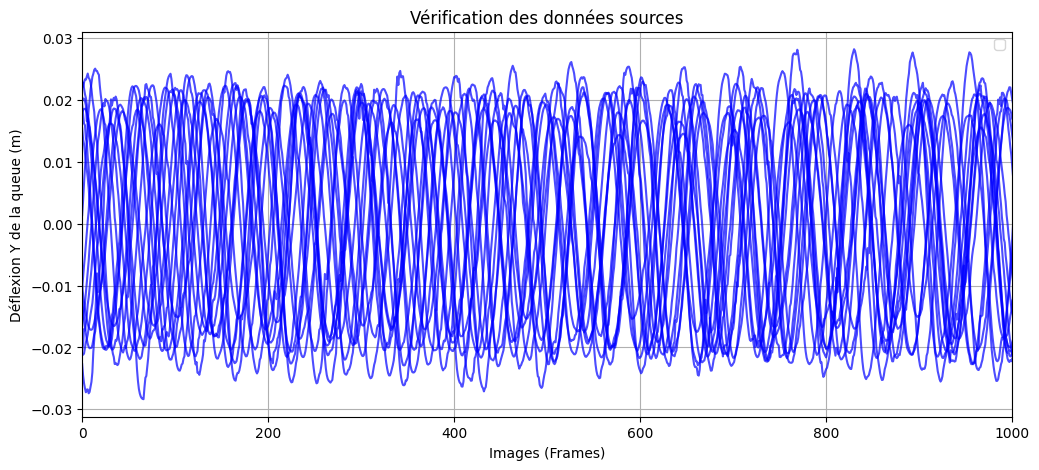

In [4]:
# Affichage
plt.figure(figsize=(12, 5))
queues = {}


for v in volts :
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    
    #mouvement brut de la queue
    queue = data['Y'][:, -1] / 1000.0
    
    #centre sur zéro pour comparer proprement
    queue = queue - np.mean(queue)

    plt.plot(queue, color='blue', alpha=0.7)


plt.title("Vérification des données sources")
plt.xlabel("Images (Frames)")
plt.ylabel("Déflexion Y de la queue (m)")
plt.legend()
plt.grid(True)
plt.xlim(0, 1000) 
plt.show()

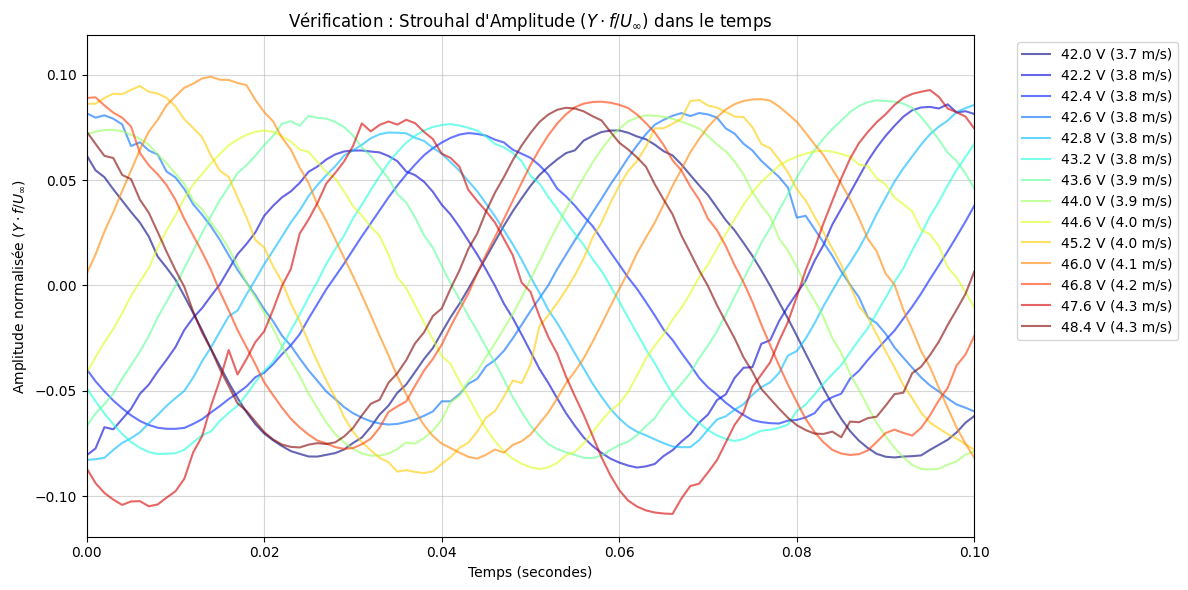

In [5]:
import matplotlib.cm as cm


plt.figure(figsize=(12, 6))    

# palette de couleurs (du bleu au rouge, volts croissants)
colors = cm.jet(np.linspace(0, 1, len(volts)))

for idx, v in enumerate(volts):
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    
    ligne_df = df_final[df_final['Volts'] == v].iloc[0]
    f_val = ligne_df['Frequence_Hz']
    U_val = ligne_df['U_vent']
    
    # Mouvement brut de la queue en mètres
    queue = data['Y'][:, -1] / 1000.0
    queue = queue - np.mean(queue) # Centrage
    
    # normalisation (Strouhal d'amplitude : Y * f / U)

    queue_normalisee = queue * f_val / U_val
    
    # axe temps (en secondes)
    temps = np.arange(len(queue_normalisee)) / 1000.0 # fps = 1000
    
    #tracé avec la couleur correspondante à la vitesse
    plt.plot(temps, queue_normalisee, color=colors[idx], alpha=0.6, label=f'{v} V ({U_val:.1f} m/s)')

plt.title(r"Vérification : Strouhal d'Amplitude ($Y \cdot f / U_{\infty}$) dans le temps")
plt.xlabel("Temps (secondes)")
plt.ylabel(r"Amplitude normalisée ($Y \cdot f / U_{\infty}$)")

plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.grid(True, alpha=0.5)

# on regarde juste le premier dixième de seconde (100 ms) pour bien voir les ondes
plt.xlim(0, 0.1) 

plt.tight_layout()
plt.show()

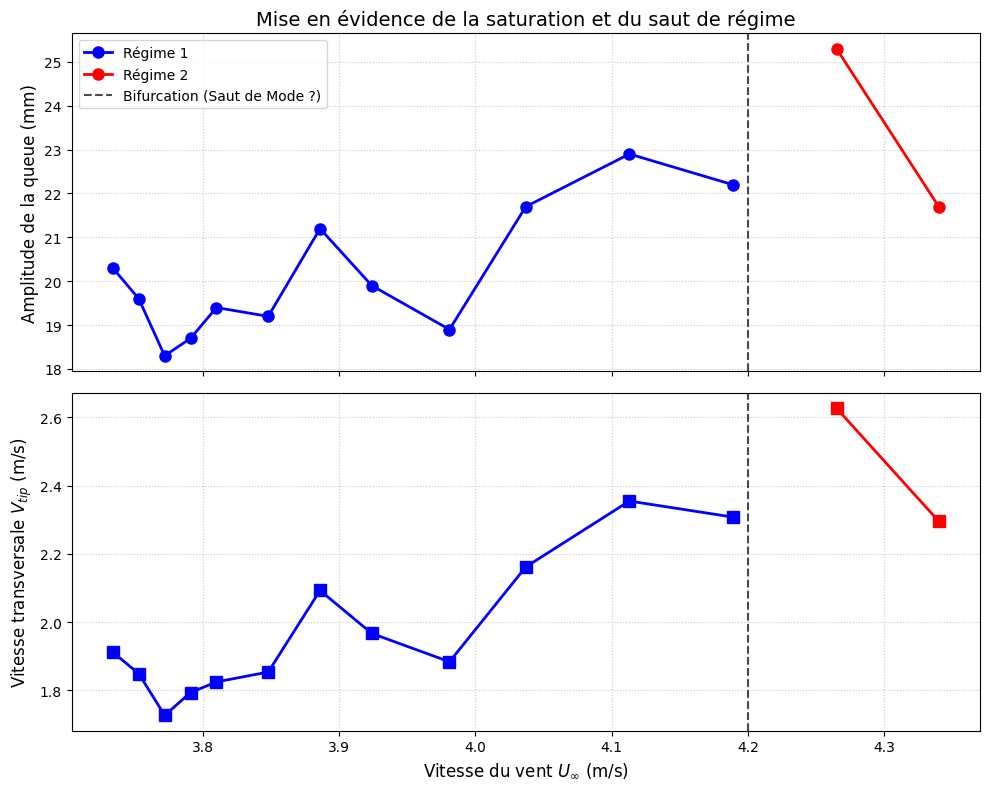

In [6]:
U = df_final['U_vent']
Amp = df_final['Amplitude_m'] * 1000  # en mm
Vtip = df_final['V_battement_ms']     # en m/s

#séparation des deux régimes
mask_R1 = df_final['Volts'] <= 46.8
mask_R2 = df_final['Volts'] > 46.8

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

#deux dômes d'amplitude
ax1.plot(U[mask_R1], Amp[mask_R1], 'bo-', markersize=8, linewidth=2, label='Régime 1')
ax1.plot(U[mask_R2], Amp[mask_R2], 'ro-', markersize=8, linewidth=2, label='Régime 2')

ax1.axvline(x=4.2, color='k', linestyle='--', alpha=0.7, label='Bifurcation (Saut de Mode ?)')
ax1.set_ylabel("Amplitude de la queue (mm)", fontsize=12)
ax1.set_title("Mise en évidence de la saturation et du saut de régime", fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

#vitesse
ax2.plot(U[mask_R1], Vtip[mask_R1], 'bs-', markersize=8, linewidth=2)
ax2.plot(U[mask_R2], Vtip[mask_R2], 'rs-', markersize=8, linewidth=2)

ax2.axvline(x=4.2, color='k', linestyle='--', alpha=0.7)
ax2.set_xlabel(r"Vitesse du vent $U_{\infty}$ (m/s)", fontsize=12)
ax2.set_ylabel(r"Vitesse transversale $V_{tip}$ (m/s)", fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

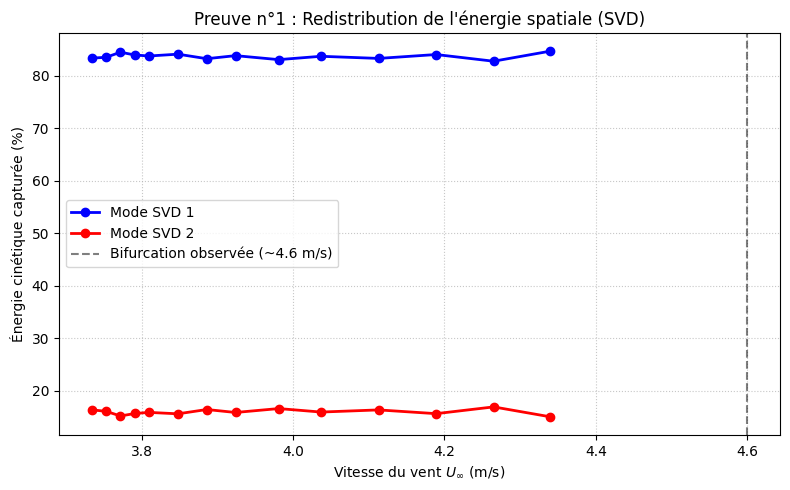

In [7]:
volts = df_final['Volts'].values
u_vents = df_final['U_vent'].values

energie_mode1 = []
energie_mode2 = []

for v in volts:
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    Y_brut = data['Y'] / 1000.0
    S_brut = data['S'][0] / 1000.0
    
    # Réaxage
    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, _, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a
        
    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    
    # SVD et calcul d'énergie
    _, Sigma, _ = np.linalg.svd(Y_centré, full_matrices=False)
    energie_totale = np.sum(Sigma**2)
    energie_modes = (Sigma**2 / energie_totale) * 100
    
    energie_mode1.append(energie_modes[0])
    energie_mode2.append(energie_modes[1])


plt.figure(figsize=(8, 5))
plt.plot(u_vents, energie_mode1, 'bo-', label='Mode SVD 1', linewidth=2)
plt.plot(u_vents, energie_mode2, 'ro-', label='Mode SVD 2', linewidth=2)

plt.axvline(x=4.6, color='k', linestyle='--', alpha=0.5, label='Bifurcation observée (~4.6 m/s)')

plt.title("Preuve n°1 : Redistribution de l'énergie spatiale (SVD)")
plt.xlabel(r"Vitesse du vent $U_{\infty}$ (m/s)")
plt.ylabel("Énergie cinétique capturée (%)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

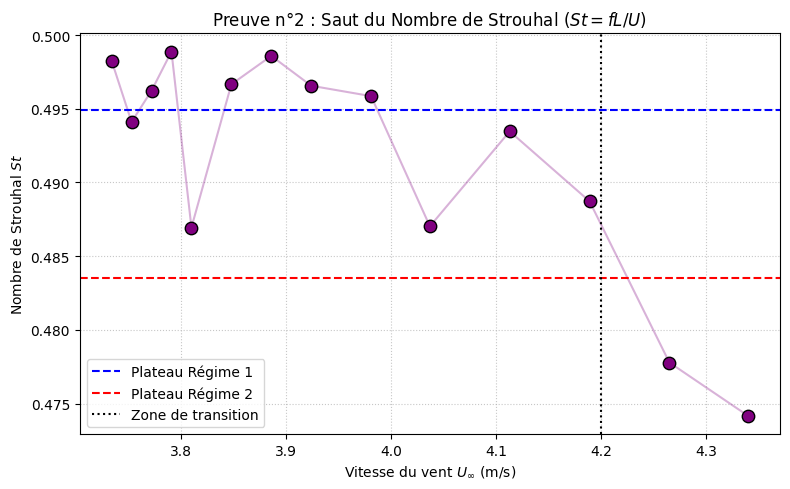

In [8]:
# L_flag = 0.125 m
Strouhal = (df_final['Frequence_Hz'] * 0.125) / df_final['U_vent']

plt.figure(figsize=(8, 5))
plt.scatter(df_final['U_vent'], Strouhal, color='purple', s=80, edgecolor='k', zorder=3)
plt.plot(df_final['U_vent'], Strouhal, color='purple', alpha=0.3) # Ligne pour lier les points

# Lignes de tendance visuelles
plt.axhline(y=np.mean(Strouhal[:10]), color='b', linestyle='--', label='Plateau Régime 1')
plt.axhline(y=np.mean(Strouhal[10:]), color='r', linestyle='--', label='Plateau Régime 2')
plt.axvline(x=4.2, color='k', linestyle=':', label='Zone de transition')

plt.title(r"Preuve n°2 : Saut du Nombre de Strouhal ($St = fL/U$)")
plt.xlabel(r"Vitesse du vent $U_{\infty}$ (m/s)")
plt.ylabel(r"Nombre de Strouhal $St$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

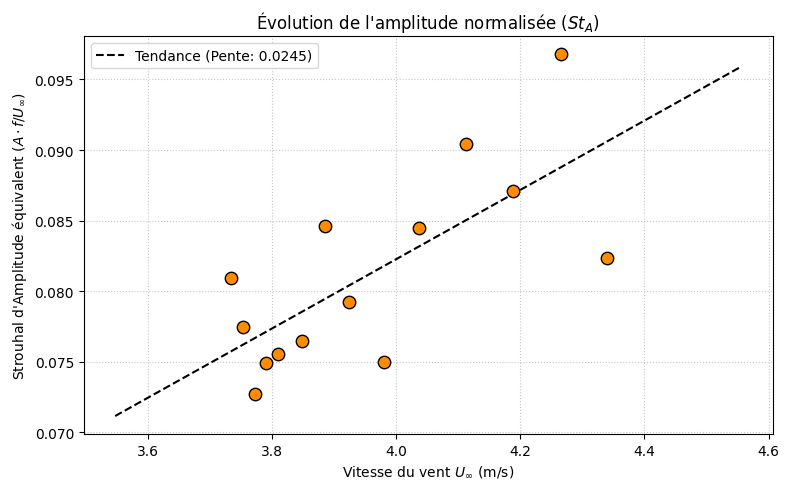

In [10]:
strouhal_amplitude_list = []
U_vent_list = []

for v in volts:
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    ligne_df = df_final[df_final['Volts'] == v].iloc[0]
    
    f_val = ligne_df['Frequence_Hz']
    U_val = ligne_df['U_vent']
    U_vent_list.append(U_val)
    
    # queue normalisée (St_A)
    queue = data['Y'][:, -1] / 1000.0
    queue = queue - np.mean(queue)
    queue_normalisee = queue * f_val / U_val
    
    # calcul du RMS de l'amplitude normalisée ==> quantifie l'écart "moyen" au zéro sur toute la vidéo
    rms_val = np.sqrt(np.mean(queue_normalisee**2))
    
    # repasser en amplitude "Crête" équivalente (pour un sinus : Crête = RMS * sqrt(2))
    amplitude_crete_equivalente = rms_val * np.sqrt(2)
    
    strouhal_amplitude_list.append(amplitude_crete_equivalente)


plt.figure(figsize=(8, 5))

plt.scatter(U_vent_list, strouhal_amplitude_list, color='darkorange', s=80, edgecolor='k', zorder=3)

slope, intercept, r_value, _, _ = linregress(U_vent_list, strouhal_amplitude_list)
U_fit = np.linspace(min(U_vent_list)*0.95, max(U_vent_list)*1.05, 10)
plt.plot(U_fit, slope * U_fit + intercept, 'k--', label=f'Tendance (Pente: {slope:.4f})')

plt.title(r"Évolution de l'amplitude normalisée ($St_A$)")
plt.xlabel(r"Vitesse du vent $U_{\infty}$ (m/s)")
plt.ylabel(r"Strouhal d'Amplitude équivalent ($A \cdot f / U_{\infty}$)")

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
#rigidité imposée

results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)


    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a


    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_t) # dt adimensionné
    
    #données réaxées pour Euler-Bernoulli 
    s_axis = S_brut / L_flag_mm_t
    Y = Y_corrige / L_flag_mm_t

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_t
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_t)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_t) * (L_flag_t**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_t) * (L_flag_t**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)


    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    

    U_svd, Sigma_svd, Vt_svd = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U_svd[:, :2] * Sigma_svd[:2], Vt_svd[:2, :])
    
    tip_signaL_flag_t = Y_propre[:, -1] / 1000.0
    
    # amplitude Statistique (RMS)
    amplitude_moyenne_t = np.std(tip_signaL_flag_t) * np.sqrt(2)
    
    # fréquence (Passages par zéro)
    zero_crossings = np.where(np.diff(np.sign(tip_signaL_flag_t)))[0]
    if len(zero_crossings) < 4:
        print(f"  -> Attention, pas assez d'oscillations détectées pour {v} V.")
        continue
        
    periodes_en_points_t = np.diff(zero_crossings[::2]) 
    periode_moyenne_sec_t = np.mean(periodes_en_points_t) / fps
    freq_precise_t = 1.0 / periode_moyenne_sec_t
    
    # vitesse instantanée pour chaque frame
    v_tip_instantanee_t = np.gradient(tip_signaL_flag_t, dt_brut) 
    
    # "Vitesse Crête Typique" avec la méthode RMS
    v_tip_reelle_t = np.std(v_tip_instantanee_t) * np.sqrt(2)
    
    #comparaison avec le modèle harmonique 
    v_tip_t = 2 * np.pi * freq_precise_t * amplitude_moyenne_t
    print(f"Vitesse Harmonique: {v_tip_t:.3f} | Vitesse Réelle: {v_tip_reelle_t:.3f}")
    m_air_displaced_t = rho_air * np.pi * H_flag_t / 4
    

#ML avec D imposé

    C_ssss_impose_t = - B_flag / (M_totale_t * (U_vent**2) * (L_flag_t**2))
    Y_tt_modifie = Y_tt_flat - (C_ssss_impose_t * Y_ssss_flat)

    X_features_contraint = np.column_stack([
     Y_ts_flat, Y_ss_flat, Y_resis_flat
    ])
    
    feature_names_contraint = ['y_ts', 'y_ss', 'y_resis']

    X_scales_contraint = np.std(X_features_contraint, axis=0)
    X_scales_contraint[X_scales_contraint == 0] = 1.0
    X_features_contraint_scaled = X_features_contraint / X_scales_contraint

    modele_contraint = Ridge(alpha=5, fit_intercept=False)
    modele_contraint.fit(X_features_contraint_scaled, Y_tt_modifie)

    vrais_coefs_contraint = modele_contraint.coef_ / X_scales_contraint

    for coef, nom in zip(vrais_coefs_contraint, feature_names_contraint):
        print(f"  Nouveau {nom} : {coef:.4f}")

    C_ts_new = vrais_coefs_contraint[0]
    C_ss_new = vrais_coefs_contraint[1]
    C_resis_new = vrais_coefs_contraint[2]

    M_air_new_t = (-C_ts_new * m_flag) / (2 + C_ts_new)
    M_totale_new_t = m_flag + M_air_new_t
    Tension_new_t = (U_vent**2) * (C_ss_new * M_totale_new_t + M_air_new_t)
    Cd_new_t = - (2 * M_totale_new_t * C_resis_new) / (rho_air * L_flag_t)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_t, 4),
        'Frequence_Hz': round(freq_precise_t, 3),
        'V_battement_ms': round(v_tip_t, 3),
        'M_air_cylindre_kg': round(m_air_displaced_t, 6),
        'M_air_SINDy_kg': round(M_air_new_t, 6),
        'Tension_new_N_m': round(Tension_new_t, 4),
        'Cd_new_SINDy': round(Cd_new_t, 3),
        'Rigidite_imposee_D': round(B_flag, 8)
    })


df_D_final = pd.DataFrame(results)
print("\n=== Synthèse Complète D imposé ===")
print(df_D_final)
df_D_final.to_csv('synthese_D_impose_complete.csv', index=False)


Traitement de la prise 42.0 V...
Vitesse Harmonique: 1.898 | Vitesse Réelle: 1.912
  Nouveau y_ts : -0.1956
  Nouveau y_ss : -0.0390
  Nouveau y_resis : -4.3914

Traitement de la prise 42.2 V...
Vitesse Harmonique: 1.823 | Vitesse Réelle: 1.849
  Nouveau y_ts : -0.1949
  Nouveau y_ss : -0.0377
  Nouveau y_resis : -4.3930

Traitement de la prise 42.4 V...
Vitesse Harmonique: 1.721 | Vitesse Réelle: 1.727
  Nouveau y_ts : -0.1942
  Nouveau y_ss : -0.0365
  Nouveau y_resis : -4.3945

Traitement de la prise 42.6 V...
Vitesse Harmonique: 1.782 | Vitesse Réelle: 1.794
  Nouveau y_ts : -0.1935
  Nouveau y_ss : -0.0353
  Nouveau y_resis : -4.3959

Traitement de la prise 42.8 V...
Vitesse Harmonique: 1.806 | Vitesse Réelle: 1.825
  Nouveau y_ts : -0.1928
  Nouveau y_ss : -0.0341
  Nouveau y_resis : -4.3974

Traitement de la prise 43.2 V...
Vitesse Harmonique: 1.847 | Vitesse Réelle: 1.854
  Nouveau y_ts : -0.1915
  Nouveau y_ss : -0.0317
  Nouveau y_resis : -4.4003

Traitement de la prise 43.6

In [12]:
#D et Cd imposés

Cd_impose = 1
results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)


    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a


    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_t) # dt adimensionné
    
    #données réaxées pour Euler-Bernoulli 
    s_axis = S_brut / L_flag_mm_t
    Y = Y_corrige / L_flag_mm_t

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_t
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_t)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_t) * (L_flag_t**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_t) * (L_flag_t**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    Q_modes = np.zeros((Y.shape[0], 2))

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)

        Q_modes[i, 0] = coefs[0]
        Q_modes[i, 1] = coefs[1]
        
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)


    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    

    U_svd, Sigma_svd, Vt_svd = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U_svd[:, :2] * Sigma_svd[:2], Vt_svd[:2, :])
    
    tip_signaL_flag_t = Y_propre[:, -1] / 1000.0
    
    # amplitude Statistique (RMS)
    amplitude_moyenne_t = np.std(tip_signaL_flag_t) * np.sqrt(2)
    
    # fréquence (Passages par zéro)
    zero_crossings = np.where(np.diff(np.sign(tip_signaL_flag_t)))[0]
    if len(zero_crossings) < 4:
        print(f"  -> Attention, pas assez d'oscillations détectées pour {v} V.")
        continue
        
    periodes_en_points_t = np.diff(zero_crossings[::2]) 
    periode_moyenne_sec_t = np.mean(periodes_en_points_t) / fps
    freq_precise_t = 1.0 / periode_moyenne_sec_t
    
    # vitesse instantanée pour chaque frame
    v_tip_instantanee_t = np.gradient(tip_signaL_flag_t, dt_brut) 
    
    # "Vitesse Crête Typique" avec la méthode RMS
    v_tip_reelle_t = np.std(v_tip_instantanee_t) * np.sqrt(2)
    
    #comparaison avec le modèle harmonique 
    v_tip_t = 2 * np.pi * freq_precise_t * amplitude_moyenne_t
    print(f"Vitesse Harmonique: {v_tip_t:.3f} | Vitesse Réelle: {v_tip_reelle_t:.3f}")

        #longueur d'onde
    idx_ref = len(s_axis) // 2
    y_ref = Y_propre[:, idx_ref]
    y_ref_mean = y_ref - np.mean(y_ref)
    
    delays = []
    s_vals_corr = []
    
    for j in range(idx_ref, len(s_axis)):
        y_s = Y_propre[:, j]
        y_s_mean = y_s - np.mean(y_s)
        
        corr = np.correlate(y_s_mean, y_ref_mean, mode='full')
        lag = corr.argmax() - (len(y_s_mean) - 1)
        
        tau = lag / fps 
        delays.append(tau)
        s_vals_corr.append(s_axis[j] * L_flag_t)
        
    slope_c, _, _, _, _ = linregress(s_vals_corr, delays)
    if slope_c != 0:
        c_onde = 1.0 / abs(slope_c)
        lam = c_onde / freq_precise_t
    else:
        c_onde, lam = 0, 0

    #dérivées ==> galerkin
    q1 = Q_modes[:, 0]
    q2 = Q_modes[:, 1]
    
    dq1 = np.gradient(q1, dt_brut)
    dq2 = np.gradient(q2, dt_brut)
    ddq1 = np.gradient(dq1, dt_brut)
    ddq2 = np.gradient(dq2, dt_brut)
    
    b_edo = 5
    q1_trunc, q2_trunc = q1[b_edo:-b_edo], q2[b_edo:-b_edo]
    dq1_trunc, dq2_trunc = dq1[b_edo:-b_edo], dq2[b_edo:-b_edo]
    ddq1_trunc, ddq2_trunc = ddq1[b_edo:-b_edo], ddq2[b_edo:-b_edo]
    
    m_air_displaced_t = rho_air * np.pi * H_flag_t / 4
    
#ML avec D et Cd imposés

    C_ssss_impose = - B_flag / (M_totale_t * (U_vent**2) * (L_flag_t**2))
    C_resis_impose = - rho_air * Cd_impose * L_flag_t / (2 * M_totale_t)
    Y_tt_modifie = Y_tt_flat - (C_ssss_impose * Y_ssss_flat) - (C_resis_impose * Y_resis_flat)

    X_features_contraint = np.column_stack([
     Y_ts_flat, Y_ss_flat
    ])
    
    feature_names_contraint = ['y_ts', 'y_ss']

    X_scales_contraint = np.std(X_features_contraint, axis=0)
    X_scales_contraint[X_scales_contraint == 0] = 1.0
    X_features_contraint_scaled = X_features_contraint / X_scales_contraint

    modele_contraint = Ridge(alpha=5, fit_intercept=False)
    modele_contraint.fit(X_features_contraint_scaled, Y_tt_modifie)

    vrais_coefs_contraint = modele_contraint.coef_ / X_scales_contraint

    for coef, nom in zip(vrais_coefs_contraint, feature_names_contraint):
        print(f"  Nouveau {nom} : {coef:.4f}")

    C_ts_new = vrais_coefs_contraint[0]
    C_ss_new = vrais_coefs_contraint[1]

    M_air_new_t = (-C_ts_new * m_flag) / (2 + C_ts_new)
    M_totale_new_t = m_flag + M_air_new_t
    Tension_new_t = (U_vent**2) * (C_ss_new * M_totale_new_t + M_air_new_t)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_t, 4),
        'Frequence_Hz': round(freq_precise_t, 3),
        'V_battement_ms': round(v_tip_t, 3),
        'M_air_cylindre_kg': round(m_air_displaced_t, 6),
        'M_air_SINDy_kg': round(M_air_new_t, 6),
        'Tension_new_N_m': round(Tension_new_t, 4),
        'Tension_adim': round(Tension_new_t/(0.5*L_flag_t*rho_air*U_vent**2), 4),
        'Cd_impose': round(Cd_impose, 3),
        'Rigidite_imposee_D': round(B_flag, 8)
    })


df_D_Cd_final = pd.DataFrame(results)
print("\n=== Synthèse Complète D&Cd imposés ===")
print(df_D_Cd_final)
df_D_Cd_final.to_csv('synthese_D_Cd_imposes_complete.csv', index=False)


Traitement de la prise 42.0 V...
Vitesse Harmonique: 1.898 | Vitesse Réelle: 1.912
  Nouveau y_ts : -0.3812
  Nouveau y_ss : -0.0969

Traitement de la prise 42.2 V...
Vitesse Harmonique: 1.823 | Vitesse Réelle: 1.849
  Nouveau y_ts : -0.3806
  Nouveau y_ss : -0.0957

Traitement de la prise 42.4 V...
Vitesse Harmonique: 1.721 | Vitesse Réelle: 1.727
  Nouveau y_ts : -0.3800
  Nouveau y_ss : -0.0945

Traitement de la prise 42.6 V...
Vitesse Harmonique: 1.782 | Vitesse Réelle: 1.794
  Nouveau y_ts : -0.3794
  Nouveau y_ss : -0.0933

Traitement de la prise 42.8 V...
Vitesse Harmonique: 1.806 | Vitesse Réelle: 1.825
  Nouveau y_ts : -0.3788
  Nouveau y_ss : -0.0921

Traitement de la prise 43.2 V...
Vitesse Harmonique: 1.847 | Vitesse Réelle: 1.854
  Nouveau y_ts : -0.3776
  Nouveau y_ss : -0.0898

Traitement de la prise 43.6 V...
Vitesse Harmonique: 2.062 | Vitesse Réelle: 2.093
  Nouveau y_ts : -0.3764
  Nouveau y_ss : -0.0876

Traitement de la prise 44.0 V...
Vitesse Harmonique: 1.951 | 

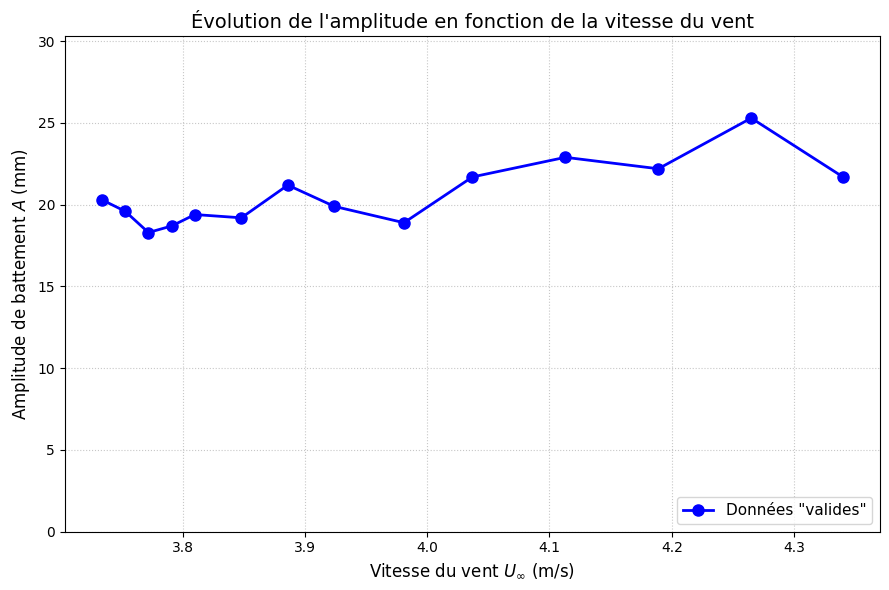

In [13]:
plt.figure(figsize=(9, 6))

#points valides = ligne pour montrer le plateau
plt.plot(df_D_Cd_final['U_vent'], df_D_Cd_final['Amplitude_m'] * 1000, 
         marker='o', linestyle='-', color='blue', linewidth=2, markersize=8, 
         label='Données "valides"')


plt.xlabel("Vitesse du vent $U_{\\infty}$ (m/s)", fontsize=12)
plt.ylabel("Amplitude de battement $A$ (mm)", fontsize=12)
plt.title("Évolution de l'amplitude en fonction de la vitesse du vent", fontsize=14)

plt.ylim(bottom=0, top=df_D_Cd_final['Amplitude_m'].max() * 1000 + 5)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

plt.show()

Régression (M_Sindy = 0.1 * M_pavé)


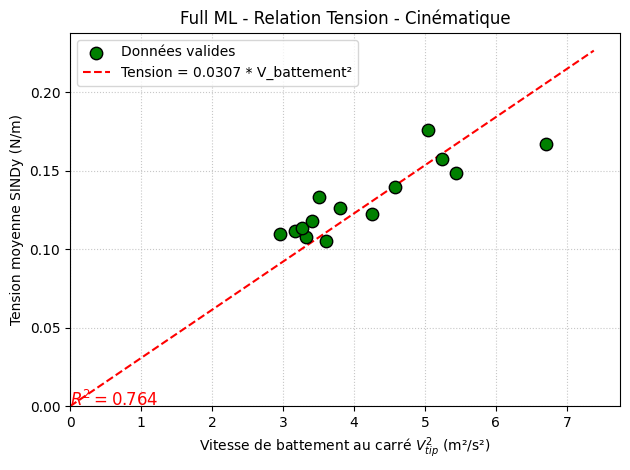

In [14]:
df_D_Cd_final.sort_values(by='U_vent')

#masse d'air
x1 = df_D_Cd_final['M_air_cylindre_kg']
y1 = df_D_Cd_final['M_air_SINDy_kg']

# régression linéaire passant par zéro (y = a*x)
a = np.linalg.lstsq(x1.values[:, np.newaxis], y1.values, rcond=None)[0][0]

x_fit1 = np.linspace(x1.min() * 0.95, x1.max() * 1.05, 100)
print(f'Régression (M_Sindy = {a:.1f} * M_pavé)')

#tension vs cinématique
x2 = df_D_Cd_final['V_battement_ms']**2
y2 = df_D_Cd_final['Tension_new_N_m']

plt.scatter(x2, y2, color='green', s=80, edgecolor='k', zorder=3, label='Données valides')

b = np.linalg.lstsq(x2.values[:, np.newaxis], y2.values, rcond=None)[0][0]

#ici trace depuis 0
x_fit2 = np.linspace(0, x2.max() * 1.1, 100)
plt.plot(x_fit2, b * x_fit2, 'r--', label=f'Tension = {b:.4f} * V_battement²')
resultat2 = linregress(x2, y2)
r2_squared = resultat2.rvalue**2
plt.text(0, 0, f'$R^2 = {r2_squared:.3f}$', fontsize=12, color='red')

plt.xlabel("Vitesse de battement au carré $V_{tip}^2$ (m²/s²)")
plt.ylabel("Tension moyenne SINDy (N/m)")
plt.title("Full ML - Relation Tension - Cinématique")
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()

plt.tight_layout()
plt.show()

écart type 0.11331538169952586


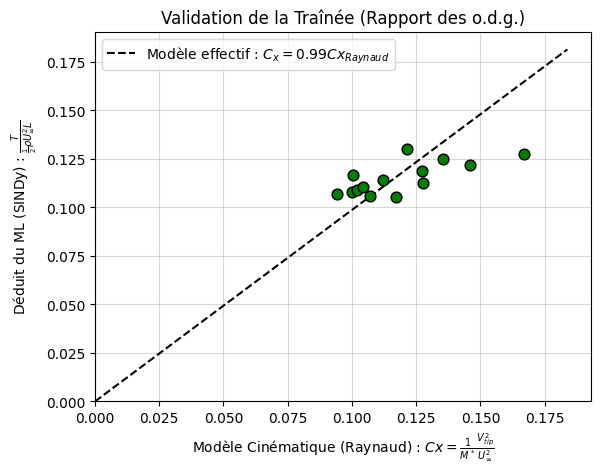

In [15]:
M_star_t = (rho_air * L_flag_t) / m_flag
# ratio moyen raynaud
v_tip_carre_t = df_D_Cd_final['V_battement_ms']**2
x3 = (1.0 / M_star_t) * (v_tip_carre_t / (df_D_Cd_final['U_vent']**2))

# Cx calculé avec la Tension trouvée par SINDy
y3 = df_D_Cd_final['Tension_new_N_m'] / (0.5 * rho_air * L_flag_t * df_D_Cd_final['U_vent']**2)

plt.scatter(x3, y3, color='green', s=60, edgecolor='k', zorder=3)

# pente effective macroscopique
gamma_moyen = np.mean(y3 / x3)

x_fit3 = np.linspace(0, x3.max()*1.1, 10)

#droite passant par zéro avec la pente moyenne
plt.plot(x_fit3, gamma_moyen * x_fit3, 'k--', 
         label=f'Modèle effectif : $C_x = {gamma_moyen:.2f} Cx_{{Raynaud}}$')

plt.xlabel(r"Modèle Cinématique (Raynaud) : $Cx = \frac{1}{M^*} \frac{V_{tip}^2}{U_{\infty}^2}$")
plt.ylabel("Déduit du ML (SINDy) : $\\frac{T}{\\frac{1}{2} \\rho U_{\\infty}^2 L}$")
plt.title(r"Validation de la Traînée (Rapport des o.d.g.)")

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.5)

#écart-type pour montrer la dispersion
std_gamma = np.std(y3 / x3)
print(f'écart type {std_gamma}')

Longueur d'onde moyenne trouvée : 0.198 m


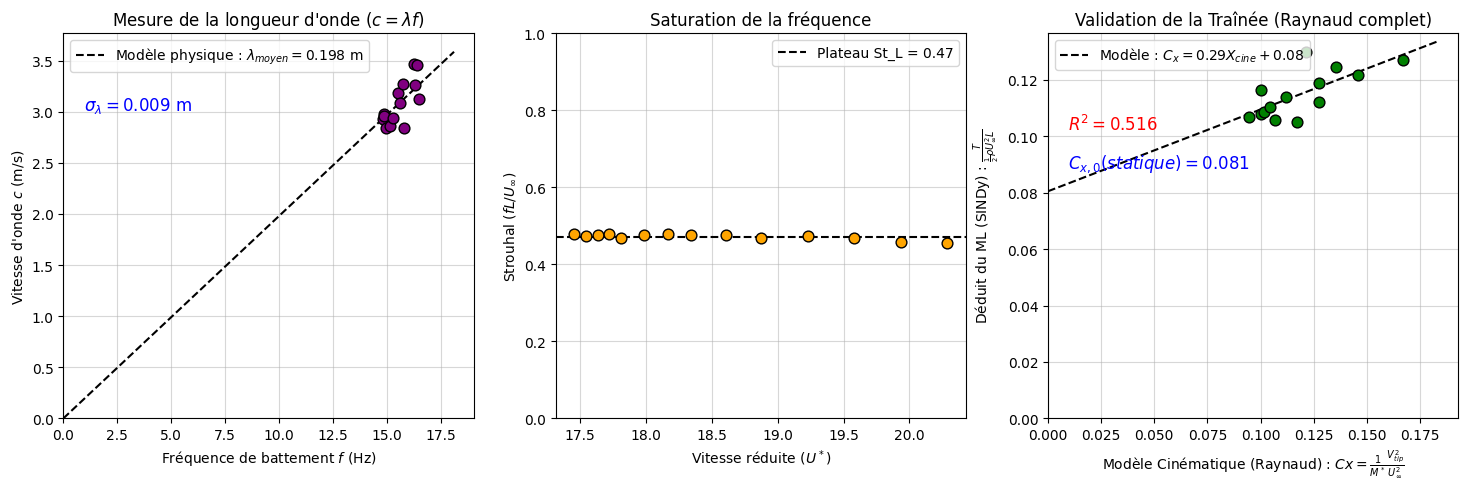

In [16]:
c_list = []
lambda_list = []
U_star_list = []

for index, row in df_D_Cd_final.iterrows():
    v = row['Volts']
    U_inf = row['U_vent']
    f = row['Frequence_Hz']

    D_flag_val = row['Rigidite_imposee_D']
    sqrt_m_sur_D = np.sqrt(m_flag / D_flag_val)
    
    #vitesse réduite U*
    U_star_t = U_inf * L_flag_t * sqrt_m_sur_D
    U_star_list.append(U_star_t)
    
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    Y = data['Y'] / 1000.0
    S = data['S'][0] / 1000.0
    
    #point de référence : le milieu du drapeau (S=L/2)
    idx_ref = len(S) // 2
    y_ref = Y[:, idx_ref]
    y_ref_mean = y_ref - np.mean(y_ref)
    
    delays = []
    s_vals = []
    
    #"corrélation croisée" pour trouver le retard (tau) sur la 2ème moitié du drapeau
    for j in range(idx_ref, len(S)):
        y_s = Y[:, j]
        y_s_mean = y_s - np.mean(y_s)
        
        corr = np.correlate(y_s_mean, y_ref_mean, mode='full')
        lag = corr.argmax() - (len(y_s_mean) - 1)
        
        tau = lag / fps  # Retard en secondes
        delays.append(tau)
        s_vals.append(S[j])
    
    #régression linéaire : tau(s) = (1/c) * s + constante
    slope, intercept, _, _, _ = linregress(s_vals, delays)
    c = 1.0 / abs(slope)
    lam = c / f
    
    c_list.append(c)
    lambda_list.append(lam)

#ajout au dataframe
df_D_Cd_final['c_onde'] = c_list
df_D_Cd_final['lambda'] = lambda_list
df_D_Cd_final['U_star'] = U_star_list

print(f"Longueur d'onde moyenne trouvée : {np.mean(df_D_Cd_final['lambda']):.3f} m")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#1 : vitesse d'onde vs fréquence (en dimensionnel) = c en fonction de f ==> pente = lambda.
x1 = df_D_Cd_final['Frequence_Hz']
y1 = df_D_Cd_final['c_onde']

ax1.scatter(x1, y1, color='purple', s=60, edgecolor='k', zorder=3)

# ratio moyen = np.mean(lambda_list)
lambda_moyen = np.mean(y1 / x1)

x_fit1 = np.linspace(0, x1.max()*1.1, 10)
ax1.plot(x_fit1, lambda_moyen * x_fit1, 'k--', 
         label=f'Modèle physique : $\\lambda_{{moyen}} = {lambda_moyen:.3f}$ m')

ax1.set_xlabel("Fréquence de battement $f$ (Hz)")
ax1.set_ylabel("Vitesse d'onde $c$ (m/s)")
ax1.set_title("Mesure de la longueur d'onde ($c = \\lambda f$)")

ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.5)

#écart-type pour montrer la dispersion
std_lambda = np.std(y1 / x1)
ax1.text(0.05, 0.80, f'$\\sigma_{{\\lambda}} = {std_lambda:.3f}$ m', transform=ax1.transAxes, fontsize=12, color='blue')

#2 : plateau de Strouhal
x2 = df_D_Cd_final['U_star']
y2 = (df_D_Cd_final['Frequence_Hz'] * L_flag_t) / df_D_Cd_final['U_vent']

ax2.scatter(x2, y2, color='orange', s=60, edgecolor='k', zorder=3)
ax2.axhline(np.mean(y2), color='k', linestyle='--', label=f'Plateau St_L = {np.mean(y2):.2f}')

ax2.set_xlabel("Vitesse réduite ($U^*$)")
ax2.set_ylabel("Strouhal ($fL/U_{\\infty}$)")
ax2.set_title("Saturation de la fréquence")
ax2.set_ylim(0, 1) 
ax2.legend()
ax2.grid(True, alpha=0.5)


# ratio moyen raynaud
v_tip_carre_t = df_D_Cd_final['V_battement_ms']**2
x3 = (1.0 / M_star_t) * (v_tip_carre_t / (df_D_Cd_final['U_vent']**2))

# Cx calculé avec la Tension trouvée par SINDy
y3 = df_D_Cd_final['Tension_new_N_m'] / (0.5 * rho_air * L_flag_t * df_D_Cd_final['U_vent']**2)

ax3.scatter(x3, y3, color='green', s=60, edgecolor='k', zorder=3)

# ordonnée à l'origine ?
slope3, intercept3, r_value3, _, _ = linregress(x3, y3)

x_fit3 = np.linspace(0, x3.max()*1.1, 10)

ax3.plot(x_fit3, slope3 * x_fit3 + intercept3, 'k--', 
         label=f'Modèle : $C_x = {slope3:.2f} X_{{cine}} + {intercept3:.2f}$')

ax3.set_xlabel(r"Modèle Cinématique (Raynaud) : $Cx = \frac{1}{M^*} \frac{V_{tip}^2}{U_{\infty}^2}$")
ax3.set_ylabel("Déduit du ML (SINDy) : $\\frac{T}{\\frac{1}{2} \\rho U_{\\infty}^2 L}$")
ax3.set_title(r"Validation de la Traînée (Raynaud complet)")

ax3.set_xlim(left=0)
ax3.set_ylim(bottom=0)
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.5)


ax3.text(0.05, 0.75, f'$R^2 = {r_value3**2:.3f}$', transform=ax3.transAxes, fontsize=12, color='red')
ax3.text(0.05, 0.65, f'$C_{{x,0}} (statique) = {intercept3:.3f}$', transform=ax3.transAxes, fontsize=12, color='blue')

#plt.tight_layout()
plt.show()

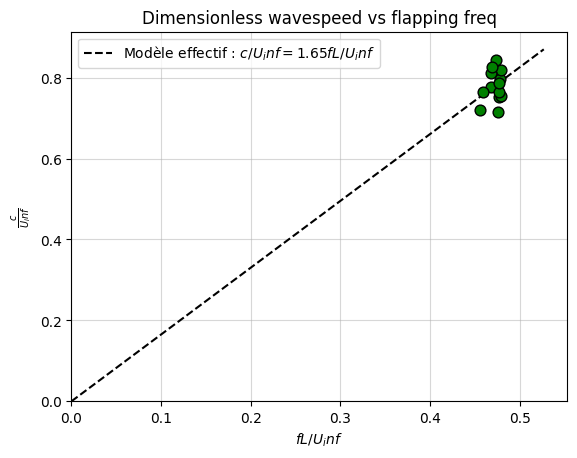

In [17]:
x3 = (df_D_Cd_final['Frequence_Hz'] * L_flag_t) / df_D_Cd_final['U_vent']

y3 = df_D_Cd_final['c_onde']/ df_D_Cd_final['U_vent']

plt.scatter(x3, y3, color='green', s=60, edgecolor='k', zorder=3)

# pente effective macroscopique
gamma_moyen = np.mean(y3 / x3)

x_fit3 = np.linspace(0, x3.max()*1.1, 10)

#droite passant par zéro avec la pente moyenne
plt.plot(x_fit3, gamma_moyen * x_fit3, 'k--', 
         label=f'Modèle effectif : $c/U_inf = {gamma_moyen:.2f} fL/U_inf$')

plt.xlabel(r"$fL/U_inf$")
plt.ylabel("$\\frac{c}{U_inf}$")
plt.title(r"Dimensionless wavespeed vs flapping freq")

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.5)

plt.show()

Longueur d'onde moyenne trouvée : 0.198 m


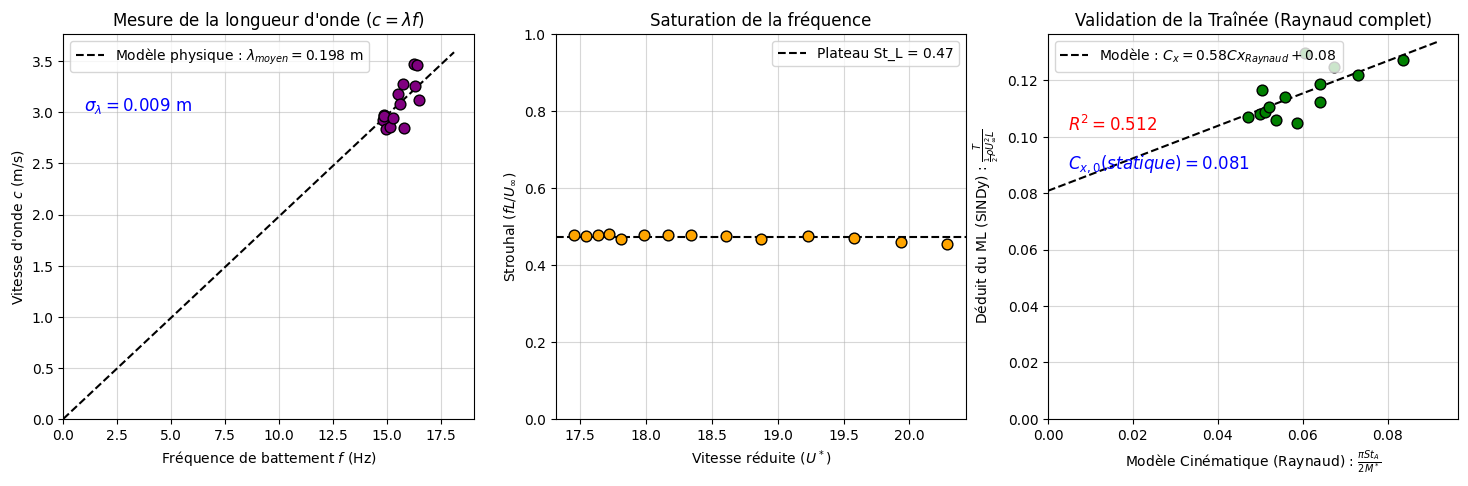

In [18]:
M_star_t = (rho_air * L_flag_t) / m_flag
c_list = []
lambda_list = []
U_star_list = []

for index, row in df_D_Cd_final.iterrows():
    v = row['Volts']
    U_inf = row['U_vent']
    f = row['Frequence_Hz']

    D_flag_val = row['Rigidite_imposee_D']
    sqrt_m_sur_D = np.sqrt(m_flag / D_flag_val)
    
    #vitesse réduite U*
    U_star_t = U_inf * L_flag_t * sqrt_m_sur_D
    U_star_list.append(U_star_t)
    
    data = np.load(f'npz_full_blue_17_12_1000Hz/{v}_1712_full_2000Hz.npz')
    Y = data['Y'] / 1000.0
    S = data['S'][0] / 1000.0
    
    #point de référence : le milieu du drapeau (S=L/2)
    idx_ref = len(S) // 2
    y_ref = Y[:, idx_ref]
    y_ref_mean = y_ref - np.mean(y_ref)
    
    delays = []
    s_vals = []
    
    #"corrélation croisée" pour trouver le retard (tau) sur la 2ème moitié du drapeau
    for j in range(idx_ref, len(S)):
        y_s = Y[:, j]
        y_s_mean = y_s - np.mean(y_s)
        
        corr = np.correlate(y_s_mean, y_ref_mean, mode='full')
        lag = corr.argmax() - (len(y_s_mean) - 1)
        
        tau = lag / fps  # Retard en secondes
        delays.append(tau)
        s_vals.append(S[j])
    
    #régression linéaire : tau(s) = (1/c) * s + constante
    slope, intercept, _, _, _ = linregress(s_vals, delays)
    c = 1.0 / abs(slope)
    lam = c / f
    
    c_list.append(c)
    lambda_list.append(lam)

#ajout au dataframe
df_D_Cd_final['c_onde'] = c_list
df_D_Cd_final['lambda'] = lambda_list
df_D_Cd_final['U_star'] = U_star_list

print(f"Longueur d'onde moyenne trouvée : {np.mean(df_D_Cd_final['lambda']):.3f} m")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#1 : vitesse d'onde vs fréquence (en dimensionnel) = c en fonction de f ==> pente = lambda.
x1 = df_D_Cd_final['Frequence_Hz']
y1 = df_D_Cd_final['c_onde']

ax1.scatter(x1, y1, color='purple', s=60, edgecolor='k', zorder=3)

# ratio moyen = np.mean(lambda_list)
lambda_moyen = np.mean(y1 / x1)

x_fit1 = np.linspace(0, x1.max()*1.1, 10)
ax1.plot(x_fit1, lambda_moyen * x_fit1, 'k--', 
         label=f'Modèle physique : $\\lambda_{{moyen}} = {lambda_moyen:.3f}$ m')

ax1.set_xlabel("Fréquence de battement $f$ (Hz)")
ax1.set_ylabel("Vitesse d'onde $c$ (m/s)")
ax1.set_title("Mesure de la longueur d'onde ($c = \\lambda f$)")

ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.5)

#écart-type pour montrer la dispersion
std_lambda = np.std(y1 / x1)
ax1.text(0.05, 0.80, f'$\\sigma_{{\\lambda}} = {std_lambda:.3f}$ m', transform=ax1.transAxes, fontsize=12, color='blue')

#2 : plateau de Strouhal
x2 = df_D_Cd_final['U_star']
y2 = (df_D_Cd_final['Frequence_Hz'] * L_flag_t) / df_D_Cd_final['U_vent']

ax2.scatter(x2, y2, color='orange', s=60, edgecolor='k', zorder=3)
ax2.axhline(np.mean(y2), color='k', linestyle='--', label=f'Plateau St_L = {np.mean(y2):.2f}')

ax2.set_xlabel("Vitesse réduite ($U^*$)")
ax2.set_ylabel("Strouhal ($fL/U_{\\infty}$)")
ax2.set_title("Saturation de la fréquence")
ax2.set_ylim(0, 1) 
ax2.legend()
ax2.grid(True, alpha=0.5)


#validation de la Traînée
v_tip_carre_t = df_D_Cd_final['V_battement_ms']**2
St_A_t = 2 * df_D_Cd_final['Frequence_Hz']*df_D_Cd_final['Amplitude_m']/ df_D_Cd_final['U_vent']
x3 = (1.0 / M_star_t) * (0.5 * (np.pi**2) * (St_A_t **2))

# Cx calculé avec la Tension trouvée par SINDy
y3 = df_D_Cd_final['Tension_new_N_m'] / (0.5 * rho_air * L_flag_t * df_D_Cd_final['U_vent']**2)

ax3.scatter(x3, y3, color='green', s=60, edgecolor='k', zorder=3)

# ordonnée à l'origine ?
slope3, intercept3, r_value3, _, _ = linregress(x3, y3)

x_fit3 = np.linspace(0, x3.max()*1.1, 10)

ax3.plot(x_fit3, slope3 * x_fit3 + intercept3, 'k--', 
         label=f'Modèle : $C_x = {slope3:.2f} Cx_{{Raynaud}} + {intercept3:.2f}$')

ax3.set_xlabel("Modèle Cinématique (Raynaud) : $\\frac{\\pi St_{A}}{2M^*} $")
ax3.set_ylabel("Déduit du ML (SINDy) : $\\frac{T}{\\frac{1}{2} \\rho U_{\\infty}^2 L}$")
ax3.set_title(r"Validation de la Traînée (Raynaud complet)")

ax3.set_xlim(left=0)
ax3.set_ylim(bottom=0)
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.5)


ax3.text(0.05, 0.75, f'$R^2 = {r_value3**2:.3f}$', transform=ax3.transAxes, fontsize=12, color='red')
ax3.text(0.05, 0.65, f'$C_{{x,0}} (statique) = {intercept3:.3f}$', transform=ax3.transAxes, fontsize=12, color='blue')

#plt.tight_layout()
plt.show()

In [19]:
# Paramètres physiques
L_flag_s = 0.125
L_flag_mm_s = 125.0
rho_50 = 1305
m_flag = rho_50 * 50e-6  
B_flag = 4.3e-5 
rho_air = 1.2 
H_flag_s = 0.026 
fps = 1000.0
volts = [50.0, 50.8, 52.0, 53.0, 54.0, 56.0, 58.0, 46.0, 46.5, 47.0, 47.5, 48.0, 48.5, 49.0, 49.5]

results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    path = f'new_data_out/{v}_slender.npz'
    data = np.load(path) 
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)


    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a


    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_s) # dt adimensionné
    
    #données réaxées pour Euler-Bernoulli 
    s_axis = S_brut / L_flag_mm_s 
    Y = Y_corrige / L_flag_mm_s 

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_s 
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_s)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_s) * (L_flag_s**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_s) * (L_flag_s**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)


    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    

    U_svd, Sigma_svd, Vt_svd = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U_svd[:, :2] * Sigma_svd[:2], Vt_svd[:2, :])
    
    tip_signaL_flag_s = Y_propre[:, -1] / 1000.0
    
    # amplitude Statistique (RMS)
    amplitude_moyenne_s = np.std(tip_signaL_flag_s) * np.sqrt(2)
    
    # fréquence (Passages par zéro)
    zero_crossings = np.where(np.diff(np.sign(tip_signaL_flag_s)))[0]
    if len(zero_crossings) < 4:
        print(f"  -> Attention, pas assez d'oscillations détectées pour {v} V.")
        continue
        
    periodes_en_points_s = np.diff(zero_crossings[::2]) 
    periode_moyenne_sec_s = np.mean(periodes_en_points_s) / fps
    freq_precise_s = 1.0 / periode_moyenne_sec_s
    
    # vitesse instantanée pour chaque frame
    v_tip_instantanee_s = np.gradient(tip_signaL_flag_s, dt_brut) 
    
    # "Vitesse Crête Typique" avec la méthode RMS
    v_tip_reelle_s = np.std(v_tip_instantanee_s) * np.sqrt(2)
    
    #comparaison avec le modèle harmonique 
    v_tip_harmonique_s = 2 * np.pi * freq_precise_s * amplitude_moyenne_s
    print(f"Vitesse Harmonique: {v_tip_harmonique_s:.3f} | Vitesse Réelle: {v_tip_reelle_s:.3f}")
    m_air_displaced_s = rho_air * np.pi * H_flag_s / 4
    

    Y_t = np.gradient(Y_pur, dt, axis=0)
    Y_tt = np.gradient(Y_t, dt, axis=0)
    Y_ts = np.gradient(Y_t, s_axis, axis=1) 

    b_time = 5 
    b_space = 5
    
    Y_tt_flat = Y_tt[b_time:-b_time, b_space:-b_space].flatten()
    Y_ts_flat = Y_ts[b_time:-b_time, b_space:-b_space].flatten()
    Y_ss_flat = Y_ss_pur[b_time:-b_time, b_space:-b_space].flatten()
    Y_ssss_flat = Y_ssss_pur[b_time:-b_time, b_space:-b_space].flatten()

    Y_s_flat = np.gradient(Y_pur, s_axis, axis=1)[b_time:-b_time, b_space:-b_space].flatten()
    Y_t_flat = Y_t[b_time:-b_time, b_space:-b_space].flatten()
    
    W_norm = Y_s_flat + Y_t_flat
    Y_resis_flat = np.abs(W_norm) * W_norm

    X_features = np.column_stack([Y_ts_flat, Y_ss_flat, Y_ssss_flat, Y_resis_flat])
    target = Y_tt_flat

    X_scales = np.std(X_features, axis=0)
    X_scales[X_scales == 0] = 1.0 
    X_features_scaled = X_features / X_scales

    modele = Ridge(alpha=5.0, fit_intercept=False) 
    modele.fit(X_features_scaled, target)
    vrais_coefs = modele.coef_ / X_scales

    C_ts = vrais_coefs[0]
    C_ss = vrais_coefs[1]
    C_ssss = vrais_coefs[2]
    C_resis = vrais_coefs[3]

    M_air_s = (-C_ts * m_flag) / (2 + C_ts)
    M_totale_s = m_flag + M_air_s
    Tension_moyenne_s = (U_vent**2) * (C_ss * M_totale_s + M_air_s)
    Cd_calcule_s = - (2 * M_totale_s * C_resis) / (rho_air * L_flag_s)
    D_calcule_s = - C_ssss * M_totale_s * (U_vent**2) * (L_flag_s**2)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_s, 4),
        'Frequence_Hz': round(freq_precise_s, 3),
        'V_harm_ms': round(v_tip_harmonique_s, 3),
        'V_battement_ms': round(v_tip_reelle_s, 3),
        'M_air_cylindre_kg': round(m_air_displaced_s, 6),
        'M_air_SINDy_kg': round(M_air_s, 6),
        'Tension_N_m': round(Tension_moyenne_s, 4),
        'Cd_SINDy': round(Cd_calcule_s, 3),
        'Rigidite_D': round(D_calcule_s, 8)
    })

df_D_slender = pd.DataFrame(results)
print("\n=== Synthèse Complète ===")
print(df_D_slender)
df_D_slender.to_csv('synthese_slender_complete.csv', index=False)

#idem en imposant B = 4.3e-5

results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    path = f'new_data_out/{v}_slender.npz'
    data = np.load(path) 
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)

    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_s) # dt adimensionné
    
    s_axis = S_brut / L_flag_mm_s 
    Y = Y_brut / L_flag_mm_s 

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_s 
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_s)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_s) * (L_flag_s**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_s) * (L_flag_s**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)

    tip_signal_s = Y_pur[:, -1] * L_flag_s  #amplitude physique en mètres
    tip_signal_s -= np.mean(tip_signal_s) 
    
    peaks, _ = find_peaks(tip_signal_s, height=0, distance=50)
    
    if len(peaks) < 2:
        print(f"  -> Attention, pas assez de battements détectés.")
        continue
        
    amplitude_moyenne_s = np.mean(tip_signal_s[peaks])
    periodes_en_points_s = np.diff(peaks)
    periode_moyenne_sec_s = np.mean(periodes_en_points_s) / fps
    freq_precise_s = 1.0 / periode_moyenne_sec_s
    
    v_tip_s = 2 * np.pi * freq_precise_s * amplitude_moyenne_s
    m_air_displaced_s = rho_air * np.pi * H_flag_s / 4

#ML avec D imposé

    C_ssss_impose = - B_flag / (M_totale_s * (U_vent**2) * (L_flag_s**2))
    Y_tt_modifie = Y_tt_flat - (C_ssss_impose * Y_ssss_flat)

    X_features_contraint = np.column_stack([
     Y_ts_flat, Y_ss_flat, Y_resis_flat
    ])
    
    feature_names_contraint = ['y_ts', 'y_ss', 'y_resis']

    X_scales_contraint = np.std(X_features_contraint, axis=0)
    X_scales_contraint[X_scales_contraint == 0] = 1.0
    X_features_contraint_scaled = X_features_contraint / X_scales_contraint

    modele_contraint = Ridge(alpha=5, fit_intercept=False)
    modele_contraint.fit(X_features_contraint_scaled, Y_tt_modifie)

    vrais_coefs_contraint = modele_contraint.coef_ / X_scales_contraint

    for coef, nom in zip(vrais_coefs_contraint, feature_names_contraint):
        print(f"  Nouveau {nom} : {coef:.4f}")

    C_ts_new = vrais_coefs_contraint[0]
    C_ss_new = vrais_coefs_contraint[1]
    C_resis_new = vrais_coefs_contraint[2]

    M_air_new_s = (-C_ts_new * m_flag) / (2 + C_ts_new)
    M_totale_new_s = m_flag + M_air_new_s
    Tension_new_s = (U_vent**2) * (C_ss_new * M_totale_new_s + M_air_new_s)
    Cd_new_s = - (2 * M_totale_new_s * C_resis_new) / (rho_air * L_flag_s)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_s, 4),
        'Frequence_Hz': round(freq_precise_s, 3),
        'V_battement_ms': round(v_tip_s, 3),
        'M_air_cylindre_kg': round(m_air_displaced_s, 6),
        'M_air_SINDy_kg': round(M_air_new_s, 6),
        'Tension_new_N_m': round(Tension_new_s, 4),
        'Cd_new_SINDy': round(Cd_new_s, 3),
        'Rigidite_imposee_D': round(B_flag, 8)
    })


df_D_slender = pd.DataFrame(results)
print("\n=== Synthèse Complète D imposé ===")
print(df_D_slender)
df_D_slender.to_csv('synthese_slender_D_impose_complete.csv', index=False)

M_star_s = (rho_air * L_flag_s) / m_flag
c_list = []
lambda_list = []
U_star_list = []

for index, row in df_D_slender.iterrows():
    v = row['Volts']
    U_inf = row['U_vent']
    f = row['Frequence_Hz']

    D_flag_val = row['Rigidite_imposee_D']
    sqrt_m_sur_D = np.sqrt(m_flag / D_flag_val)
    
    #vitesse réduite U*
    U_star_s = U_inf * L_flag_s * sqrt_m_sur_D
    U_star_list.append(U_star_s)
    
    data = np.load(f'new_data_out/{v}_slender.npz')
    Y = data['Y'] / 1000.0
    S = data['S'][0] / 1000.0
    
    #point de référence : le milieu du drapeau (S=L/2)
    idx_ref = len(S) // 2
    y_ref = Y[:, idx_ref]
    y_ref_mean = y_ref - np.mean(y_ref)
    
    delays = []
    s_vals = []
    
    #"corrélation croisée" pour trouver le retard (tau) sur la 2ème moitié du drapeau
    for j in range(idx_ref, len(S)):
        y_s = Y[:, j]
        y_s_mean = y_s - np.mean(y_s)
        
        corr = np.correlate(y_s_mean, y_ref_mean, mode='full')
        lag = corr.argmax() - (len(y_s_mean) - 1)
        
        tau = lag / fps  # Retard en secondes
        delays.append(tau)
        s_vals.append(S[j])
    
    #régression linéaire : tau(s) = (1/c) * s + constante
    slope, intercept, _, _, _ = linregress(s_vals, delays)
    c = 1.0 / abs(slope)
    lam = c / f
    
    c_list.append(c)
    lambda_list.append(lam)

#ajout au dataframe
df_D_slender['c_onde'] = c_list
df_D_slender['lambda'] = lambda_list
df_D_slender['U_star'] = U_star_list


Traitement de la prise 50.0 V...
Vitesse Harmonique: 1.413 | Vitesse Réelle: 1.444

Traitement de la prise 50.8 V...
Vitesse Harmonique: 1.160 | Vitesse Réelle: 1.207

Traitement de la prise 52.0 V...
Vitesse Harmonique: 2.051 | Vitesse Réelle: 2.056

Traitement de la prise 53.0 V...
Vitesse Harmonique: 2.196 | Vitesse Réelle: 2.199

Traitement de la prise 54.0 V...
Vitesse Harmonique: 1.560 | Vitesse Réelle: 1.565

Traitement de la prise 56.0 V...
Vitesse Harmonique: 1.620 | Vitesse Réelle: 1.627

Traitement de la prise 58.0 V...
Vitesse Harmonique: 1.422 | Vitesse Réelle: 1.429

Traitement de la prise 46.0 V...
Vitesse Harmonique: 1.311 | Vitesse Réelle: 1.323

Traitement de la prise 46.5 V...
Vitesse Harmonique: 1.448 | Vitesse Réelle: 1.461

Traitement de la prise 47.0 V...
Vitesse Harmonique: 1.612 | Vitesse Réelle: 1.644

Traitement de la prise 47.5 V...
Vitesse Harmonique: 1.622 | Vitesse Réelle: 1.667

Traitement de la prise 48.0 V...
Vitesse Harmonique: 1.831 | Vitesse Réelle

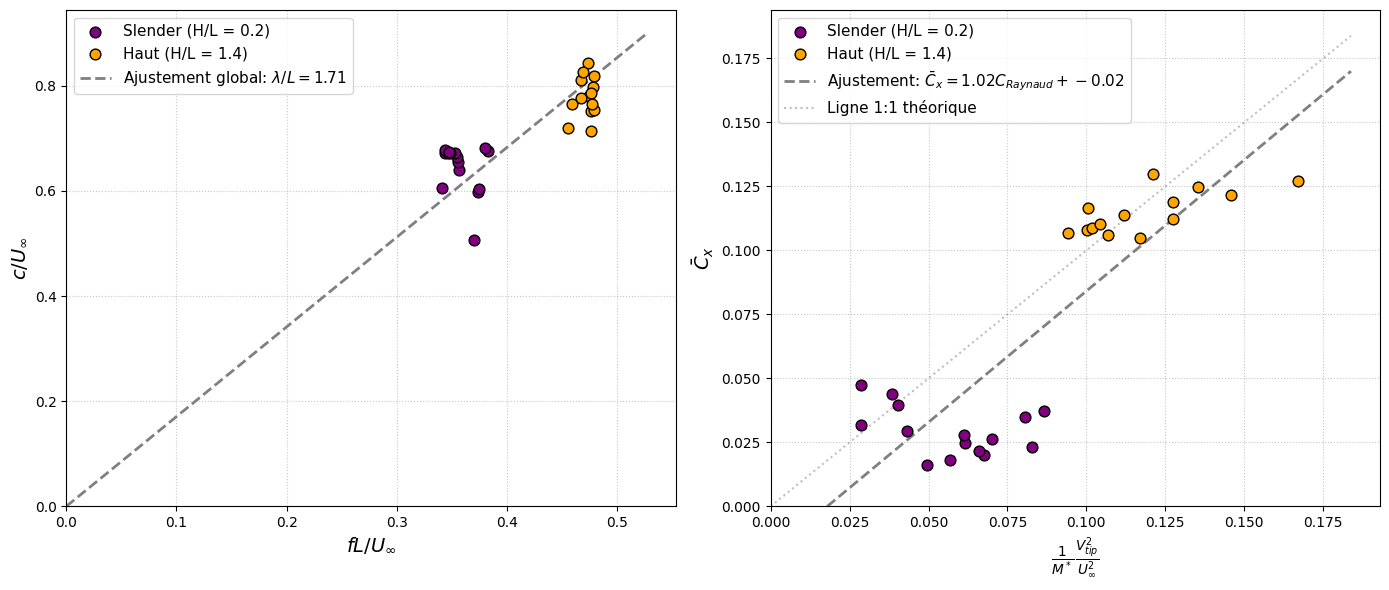

In [20]:
L_flag_s = 0.125  # Slender
M_star_s = (1.2 * L_flag_s) / (1305 * 50e-6)

L_flag_t = 0.120  # Tall
M_star_t = (1.2 * L_flag_t) / (1305 * 50e-6)

# longueur d'onde
x1_s = (df_D_slender['Frequence_Hz'] * L_flag_s) / df_D_slender['U_vent']
y1_s = df_D_slender['c_onde'] / df_D_slender['U_vent']

x1_t = (df_D_Cd_final['Frequence_Hz'] * L_flag_t) / df_D_Cd_final['U_vent']
y1_t = df_D_Cd_final['c_onde'] / df_D_Cd_final['U_vent']

# trainée
x2_s = (1.0 / M_star_s) * (df_D_slender['V_battement_ms']**2 / df_D_slender['U_vent']**2)
y2_s = df_D_slender['Tension_new_N_m'] / (0.5 * 1.2 * L_flag_s * df_D_slender['U_vent']**2)

x2_t = (1.0 / M_star_t) * (df_D_Cd_final['V_battement_ms']**2 / df_D_Cd_final['U_vent']**2)
y2_t = df_D_Cd_final['Tension_new_N_m'] / (0.5 * 1.2 * L_flag_t * df_D_Cd_final['U_vent']**2)

# concaténer régressions globales
x1_global = np.concatenate([x1_s, x1_t])
y1_global = np.concatenate([y1_s, y1_t])

x2_global = np.concatenate([x2_s, x2_t])
y2_global = np.concatenate([y2_s, y2_t])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# gradient couleur comme Raynaud
color_s = 'purple'  # Faible H/L
color_t = 'orange'  # Fort H/L

#  Longueur d'onde adimensionnée (c/U vs fL/U)
ax1.scatter(x1_s, y1_s, color=color_s, s=60, edgecolor='k', label='Slender (H/L = 0.2)', zorder=3)
ax1.scatter(x1_t, y1_t, color=color_t, s=60, edgecolor='k', label='Haut (H/L = 1.4)', zorder=3)

# Régression globale passant par zéro (y = a*x) ==> a = lambda / L
slope1 = np.linalg.lstsq(x1_global[:, np.newaxis], y1_global, rcond=None)[0][0]

x_fit1 = np.linspace(0, max(x1_global)*1.1, 100)
ax1.plot(x_fit1, slope1 * x_fit1, color='gray', linestyle='--', linewidth=2, 
         label=f'Ajustement global: $\\lambda/L = {slope1:.2f}$')

ax1.set_xlabel(r"$f L / U_{\infty}$", fontsize=14)
ax1.set_ylabel(r"$c / U_{\infty}$", fontsize=14)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

# validation trainée
ax2.scatter(x2_s, y2_s, color=color_s, s=60, edgecolor='k', label='Slender (H/L = 0.2)', zorder=3)
ax2.scatter(x2_t, y2_t, color=color_t, s=60, edgecolor='k', label='Haut (H/L = 1.4)', zorder=3)

# rég + ordonnée à l'origine (y = a*x + b)
slope2, intercept2, r_value2, _, _ = linregress(x2_global, y2_global)

x_fit2 = np.linspace(0, max(x2_global)*1.1, 100)
ax2.plot(x_fit2, slope2 * x_fit2 + intercept2, color='gray', linestyle='--', linewidth=2,
         label=f'Ajustement: $\\bar{{C}}_x = {slope2:.2f} C_{{Raynaud}} + {intercept2:.2f}$')

#ligne 1:1 de Raynaud pour comparer
ax2.plot(x_fit2, x_fit2, color='gray', linestyle=':', alpha=0.5, label='Ligne 1:1 théorique')

ax2.set_xlabel(r"$\frac{1}{M^*} \frac{V_{tip}^2}{U_{\infty}^2}$", fontsize=14)
ax2.set_ylabel(r"$\bar{C}_x$", fontsize=14)
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Équations Couplées de Galerkin
ddq1 = (-119296.30)*q1 + (189880.03)*q2 + (-2031.63)*dq1 + (-3240.36)*dq2
ddq2 = (67674.56)*q1 + (-130676.47)*q2 + (1276.80)*dq1 + (2031.81)*dq2


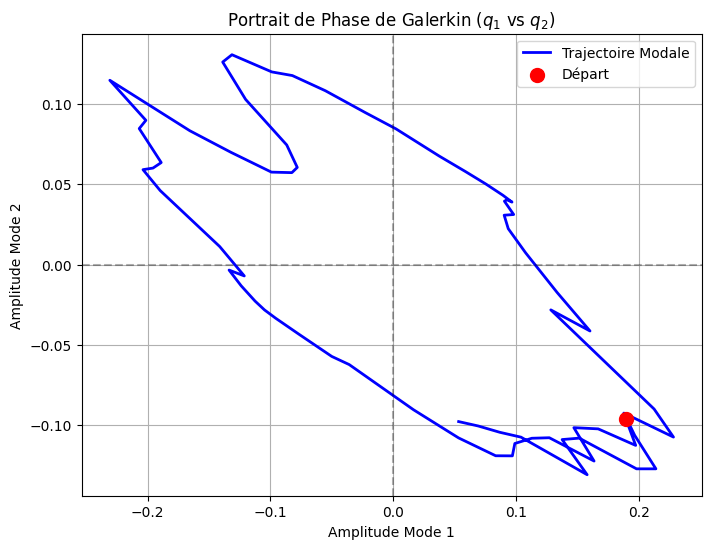

In [23]:
import matplotlib.pyplot as plt

# pour la projection de Galerkin
X_edo = np.column_stack([q1_trunc, q2_trunc, dq1_trunc, dq2_trunc])

noms_edo = ['q1', 'q2', 'dq1', 'dq2']

# standardiser
X_edo_scales = np.std(X_edo, axis=0)
X_edo_scaled = X_edo / X_edo_scales

#modèle pour l'accélération du Mode 1 (ddq1)
modele_q1 = Ridge(alpha=1.0, fit_intercept=False)
modele_q1.fit(X_edo_scaled, ddq1_trunc)
coefs_q1 = modele_q1.coef_ / X_edo_scales

#modèle pour l'accélération du Mode 2 (ddq2)
modele_q2 = Ridge(alpha=1.0, fit_intercept=False)
modele_q2.fit(X_edo_scaled, ddq2_trunc)
coefs_q2 = modele_q2.coef_ / X_edo_scales

print("Équations Couplées de Galerkin")
eq1 = "ddq1 = " + " + ".join([f"({c:.2f})*{n}" for c, n in zip(coefs_q1, noms_edo)])
eq2 = "ddq2 = " + " + ".join([f"({c:.2f})*{n}" for c, n in zip(coefs_q2, noms_edo)])
print(eq1)
print(eq2)

# portrait de phase modal
plt.figure(figsize=(8, 6))

#orbite d'un cycle (ex: sur une fraction de seconde)
plt.plot(q1_trunc[:70], q2_trunc[:70], 'b-', linewidth=2, label="Trajectoire Modale")
plt.scatter(q1_trunc[0], q2_trunc[0], color='red', s=100, label="Départ", zorder=5)

plt.xlabel("Amplitude Mode 1")
plt.ylabel("Amplitude Mode 2")
plt.title("Portrait de Phase de Galerkin ($q_1$ vs $q_2$)")
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()